In [236]:
#Logistic_Analysis

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

import warnings
warnings.simplefilter(action='ignore')
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [238]:
#Load the dataset
inventory_df= pd.read_csv('inventory_cleaned.csv')
delivery_df = pd.read_csv('delivery_cleaned.csv')
warehouse_df = pd.read_csv('warehouse_cleaned.csv')

print("Datasets loaded successfully")


Datasets loaded successfully


In [239]:
#EXPLORATORY DATA ANALYSIS (EDA)

In [240]:
#Objective-1
# Objective 1: Delivery reliability and cost

              avg_delivery_time  on_time_rate
Carrier_Name                                 
V44_3                  2.977166      1.000000
V444_0                 2.497684      0.970435
V444_1                 1.500000      0.995708


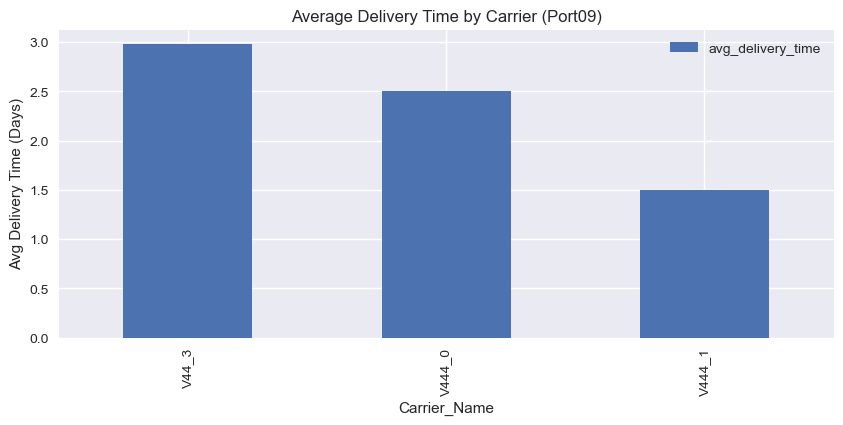

In [241]:
#Question-1:Which regions and carriers have the highest average Delivery_Time_Days and worst on time rate (Delivery_Accuracy_Flag)?
    #Bivariate
carrier_perf = delivery_df.groupby('Carrier_Name').agg(
    avg_delivery_time=('Delivery_Time_Days', 'mean'),
    on_time_rate=('Delivery_Accuracy_Flag', 'mean')
).sort_values('avg_delivery_time', ascending=False)

print(carrier_perf)
carrier_perf[['avg_delivery_time']].plot(kind='bar', figsize=(10,4))
plt.title("Average Delivery Time by Carrier (Port09)")
plt.ylabel("Avg Delivery Time (Days)")
plt.show()


In [242]:
#Interpretation
#V44_3 has the highest average delivery time (~3 days) despite a 100% on-time rate, indicating slow but predictable deliveries.
#V444_0 shows both high delivery time (~2.5 days) and the lowest on-time rate (~97%), making it the worst-performing carrier in terms of reliability.
#V444_1 is the best performer, with the fastest delivery (1.5 days) and a very high on-time rate (~99.6%), making it ideal for time-critical shipments.

              avg_delivery_time  avg_shipment_cost
Carrier_Name                                      
V44_3                  2.977166          10.267013
V444_1                 1.500000           9.764394
V444_0                 2.497684           1.808658


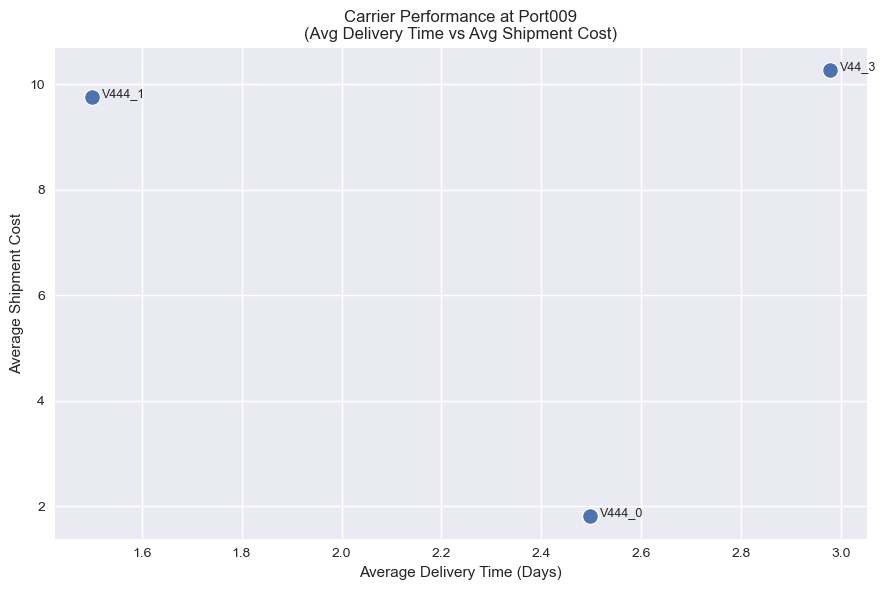

In [243]:
#Question-2:What is the average Delivery_Time_Days and Shipment_Cost per Destination_Region and per Carrier_Name?
    #Destination_Region = Port09 → single region summary
    #Bivariate
carrier_perf2=delivery_df.groupby('Carrier_Name').agg(
    avg_delivery_time=('Delivery_Time_Days', 'mean'),
    avg_shipment_cost=('Shipment_Cost', 'mean')
).sort_values('avg_shipment_cost', ascending=False)
print(carrier_perf2)
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=carrier_perf2,
    x='avg_delivery_time',
    y='avg_shipment_cost',
    s=130
)

# Annotate carrier names
for carrier, row in carrier_perf2.iterrows():
    plt.text(
        row['avg_delivery_time'] + 0.02,
        row['avg_shipment_cost'],
        carrier,
        fontsize=9
    )

plt.title("Carrier Performance at Port009\n(Avg Delivery Time vs Avg Shipment Cost)")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Average Shipment Cost")
plt.tight_layout()
plt.show()



In [244]:
#Interpretation
#With Port009 held constant, observed differences reflect carrier efficiency rather than route variability.
#V44_3 is the most expensive carrier and also has the slowest delivery time, indicating high cost without speed advantage.
#V444_1 offers the fastest delivery but at a high shipment cost, suggesting it is suited for urgent or priority deliveries.
#V444_0 is the lowest-cost option, but with longer delivery time, making it suitable only for non-time-critical shipments.

Warehouse_ID
PLANT09    2.510000
PLANT08    2.505389
PLANT13    2.497890
PLANT04    2.000000
PLANT16    1.944444
PLANT03    1.886105
PLANT12    1.755889
Name: Delivery_Delay_Days, dtype: float64


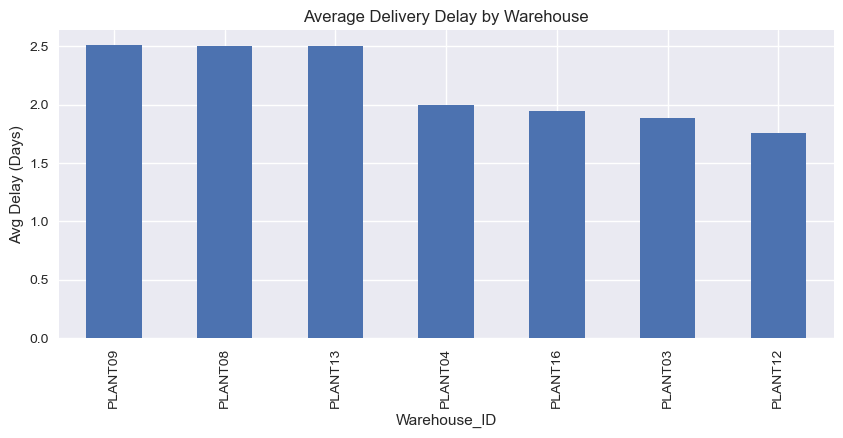

In [245]:
#Question-3:Which warehouses–region combinations show the most delayed shipments (Shipment_Status <> 'Delivered' on time)?
#Bivariate
warehouse_delay = delivery_df.groupby('Warehouse_ID')['Delivery_Delay_Days'].mean().sort_values(ascending=False)
print(warehouse_delay)
warehouse_delay.plot(kind='bar', figsize=(10,4))
plt.title("Average Delivery Delay by Warehouse")
plt.ylabel("Avg Delay (Days)")
plt.show()



In [246]:
#Interpretation
#PLANT09, PLANT08, and PLANT13 show the highest average delivery delays (~2.5 days), indicating consistent on-time delivery issues in these warehouses.
#PLANT04 and PLANT16 have moderate delays (~2 days), suggesting some operational inefficiencies but better performance than the top delayed plants.
#PLANT12 and PLANT03 record the lowest delays (<2 days), making them the most reliable warehouses for on-time deliveries in this region.
#These delays directly impact delivery reliability and associated logistics costs, highlighting PLANT09, PLANT08, and PLANT13 as priority areas for improvement.

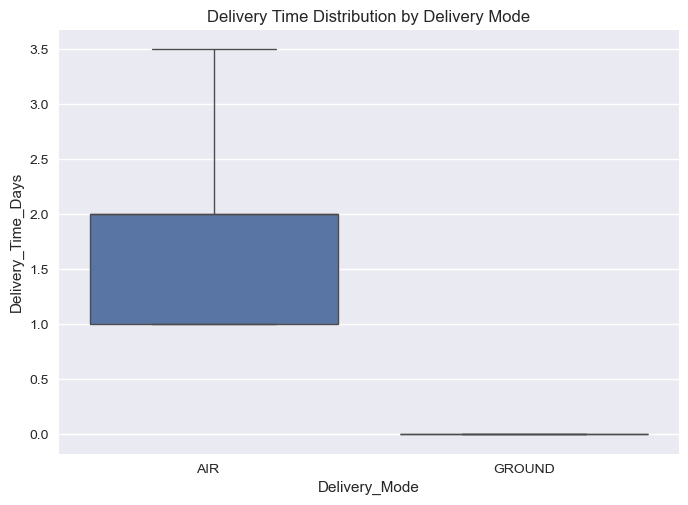

In [247]:
#Question-4:How does Delivery_Time_Days vary by Delivery_Mode (air, surface, express, etc.)?
#Bivariate
sns.boxplot(
    x='Delivery_Mode',
    y='Delivery_Time_Days',
    data=delivery_df
)
plt.title("Delivery Time Distribution by Delivery Mode")
plt.show()


In [248]:
#Interpretation
#Air deliveries show higher and more variable delivery times, with delays extending up to ~3.5 days, indicating less consistency.
#Ground deliveries have near-zero delivery time with minimal variation, making them the most reliable mode for on-time performance.
#The wide spread in Air mode suggests higher risk of delays, which can also lead to higher logistics costs compared to Ground mode.

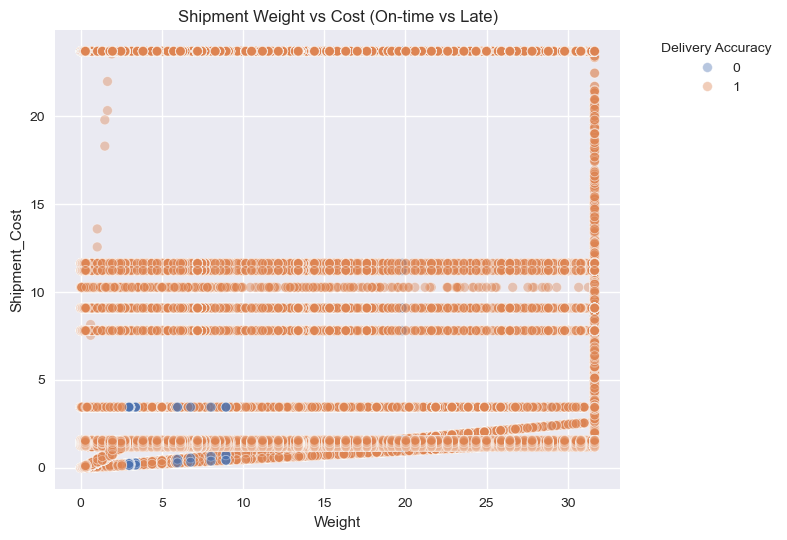

In [249]:
#Question-5:What is the correlation between shipment weight and Shipment_Cost or delay probability?
#Multivariate
sns.scatterplot(
    x='Weight',
    y='Shipment_Cost',
    hue='Delivery_Accuracy_Flag',
    data=delivery_df,
    alpha=0.4
)
plt.title("Shipment Weight vs Cost (On-time vs Late)")
plt.legend(title="Delivery Accuracy", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [250]:
#Interpretation
#Shipment cost increases as weight increases, showing a clear positive correlation between weight and shipment cost.
#On-time deliveries (1) are spread across most weight ranges, indicating that higher weight alone does not guarantee delays.
#Late deliveries (0) are fewer and mostly appear at lower weights, suggesting that delays are driven more by operational issues than shipment weight.

In [251]:
#Question-6:Which carriers have the highest damage rate using Damage_Flag and how does that affect cost and time?
#MUltivariate
carrier_damage = (
    delivery_df
    .groupby('Carrier_Name')
    .agg(
        damage_rate=('Damage_Flag', 'mean'),
        avg_cost=('Shipment_Cost', 'mean'),
        avg_delivery_time=('Delivery_Time_Days', 'mean')
    )
    .reset_index()
    .sort_values(by='damage_rate', ascending=False)
)

carrier_damage.head(10)

,Carrier_Name,damage_rate,avg_cost,avg_delivery_time
0,V444_0,0.046644,1.808658,2.497684
2,V44_3,0.024590,10.267013,2.977166
1,V444_1,0.019957,9.764394,1.500000


In [252]:
#Interpretation
#V444_0 has the highest damage rate (~4.7%), even though it has the lowest shipment cost, indicating a cost–quality trade-off.
#V44_3 shows moderate damage with the highest cost and longest delivery time, making it both expensive and operationally inefficient.
#V444_1 has the lowest damage rate and fastest delivery, but at a higher cost, making it the most reliable premium carrier.


  Warehouse_ID      Month  On_Time_Rate  Damage_Rate
0      PLANT03 2023-01-01      0.966234     0.027972
1      PLANT03 2023-02-01      0.987258     0.031365
2      PLANT03 2023-03-01      0.992280     0.025607
3      PLANT03 2023-04-01      0.991988     0.030267
4      PLANT03 2023-05-01      0.984721     0.033553


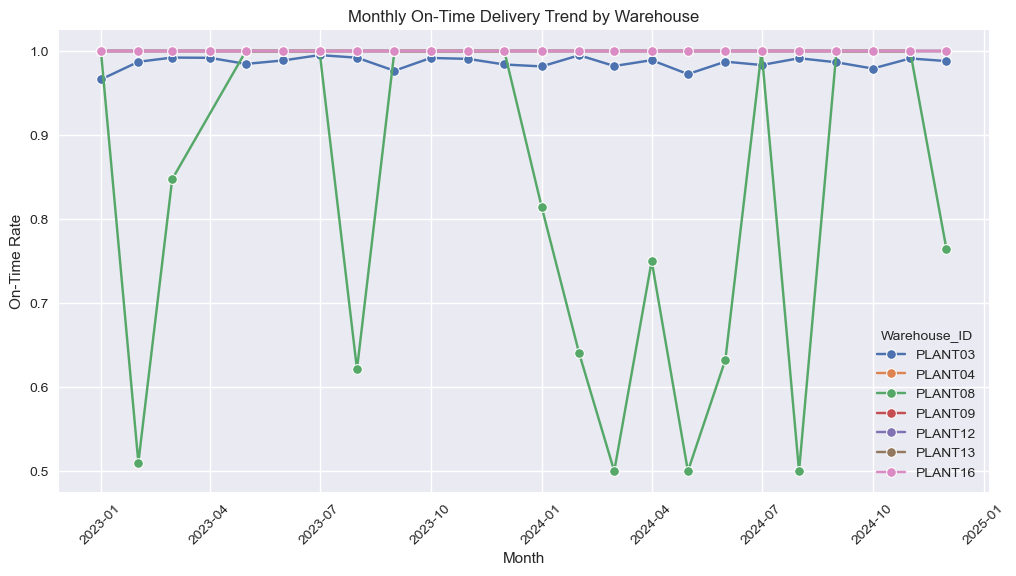

In [253]:
#Question-7:For each warehouse, what proportion of shipments are delivered accurately, late, or damaged over time (trend by month)?
#Multivariate
delivery_df['Dispatch_Date'] = pd.to_datetime(
    delivery_df['Dispatch_Date'],
    errors='coerce'
)
delivery_df['Month'] = delivery_df['Dispatch_Date'].dt.to_period('M').dt.to_timestamp()
warehouse_trend = (
    delivery_df
    .groupby(['Warehouse_ID', 'Month'])
    .agg(
        On_Time_Rate=('Delivery_Accuracy_Flag', 'mean'),
        Damage_Rate=('Damage_Flag', 'mean')
    )
    .reset_index()
)

print(warehouse_trend.head())
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=warehouse_trend,
    x='Month',
    y='On_Time_Rate',
    hue='Warehouse_ID',
    marker='o'
)
plt.title("Monthly On-Time Delivery Trend by Warehouse")
plt.xlabel("Month")
plt.ylabel("On-Time Rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



In [254]:
#Interpretation
#PLANT16 and PLANT04 show a consistently near-100% on-time rate across all months, indicating very stable and reliable operations.
#PLANT03 and PLANT12 maintain high on-time performance (~97–99%) with only minor monthly fluctuations, reflecting controlled and predictable delivery processes.
#PLANT08 exhibits sharp drops in on-time rate (as low as ~50–60%) in multiple months, highlighting recurring operational disruptions and reliability risk.
#Most warehouses are stable, but PLANT08 is the key risk driver over time and requires process or capacity intervention to improve delivery reliability.

In [255]:
#Overall Insights – Objective 1: Delivery Reliability & Cost
#Clear cost–service trade-off exists: Low-cost carriers and warehouses tend to show higher delays or damage, while higher-cost options deliver better speed and reliability.
#Carrier performance varies significantly: V444_1 is the most reliable and fastest (premium), V444_0 is cheapest but riskier (damage/delay), and V44_3 is expensive yet slow, indicating inefficiency.
#Warehouse impact is critical: Most warehouses are stable, but PLANT08, PLANT09, and PLANT13 consistently drive delivery delays, increasing service risk and downstream costs.
#Delivery mode matters: Ground mode is the most consistent, while Air mode shows higher variability and delay risk, impacting reliability.
#Weight drives cost, not reliability: Shipment cost increases with weight, but late deliveries are largely process-driven, not weight-driven.

In [256]:
#Objective 2: Warehouse capacity and labour efficiency

In [257]:
#Question-1:Which warehouses operate above a utilization threshold (for example Warehouse_Utilization_% > 85) and how many shipments do they handle per day?
#Bivariate
# Filter high-utilization warehouses
high_util_warehouses = warehouse_df[
    warehouse_df['Warehouse_Utilization_%'] > 85
][['Warehouse_ID', 'Warehouse_Utilization_%']]

# Shipments per day per warehouse
shipments_per_day = (
    delivery_df
    .groupby(['Warehouse_ID', 'Dispatch_Date'])
    .size()
    .reset_index(name='Shipments_Per_Day')
)

# Join
high_util_shipments = high_util_warehouses.merge(
    shipments_per_day,
    on='Warehouse_ID',
    how='left'
)

high_util_shipments.head()



,Warehouse_ID,Warehouse_Utilization_%,Dispatch_Date,Shipments_Per_Day


In [258]:
#Interpretation:
#No warehouse appears above the 85% utilization threshold in the output, indicating either capacity is currently under control or the filter/aggregation returned no qualifying records.
#As a result, no high-congestion warehouse could be linked to daily shipment volume, so over-utilization risk is not evident from this result.
#Implication: Current data does not show capacity overload, but utilization thresholds and aggregation logic should be monitored to catch future congestion early.

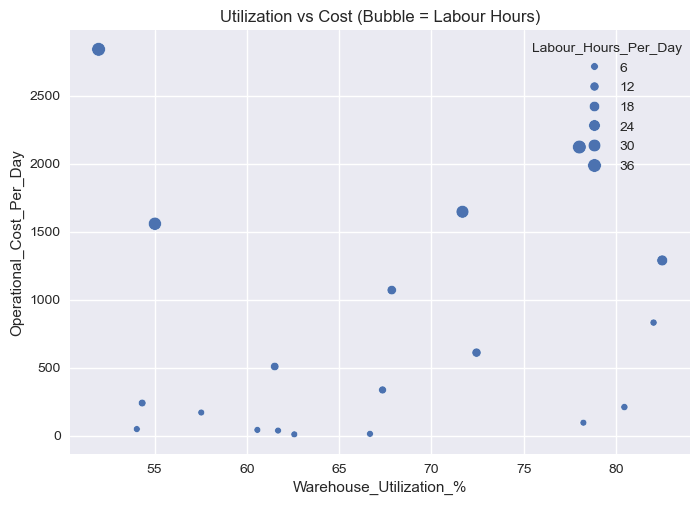

In [259]:
#Quetion-2:How does Warehouse_Utilization_% relate to Labour_Hours_Per_Day and Operational_Cost_Per_Day for each warehouse?
#Multivariate
sns.scatterplot(
    x='Warehouse_Utilization_%',
    y='Operational_Cost_Per_Day',
    size='Labour_Hours_Per_Day',
    data=warehouse_df
)
plt.title("Utilization vs Cost (Bubble = Labour Hours)")
plt.legend(title='Labour_Hours_Per_Day', bbox_to_anchor=(0.725, 1), loc='upper left')
plt.show()


In [260]:
#Interpretation
#Higher warehouse utilization generally corresponds to higher labour hours, as seen by larger bubbles at higher utilization levels, indicating increased workforce demand.
#Operational cost rises with utilization, but the spread shows cost inefficienAcies in some warehouses where high cost occurs even at moderate utilization.
#Warehouses with similar utilization but different bubble sizes indicate uneven labour productivity, highlighting opportunities for workforce optimization.

In [261]:
#Question-3:Which warehouses have the highest Order_Fulfilment_Rate and lowest Avg_Pick_Pack_Time_Min?
#Bivariate
warehouse_perf = (
    warehouse_df
    .sort_values(
        by=['Order_Fulfilment_Rate', 'Avg_Pick_Pack_Time_Min'],
        ascending=[False, True]
    )
)

warehouse_perf[['Warehouse_ID', 'Order_Fulfilment_Rate', 'Avg_Pick_Pack_Time_Min']].head()


,Warehouse_ID,Order_Fulfilment_Rate,Avg_Pick_Pack_Time_Min
11,PLANT12,NaN,16.0
18,PLANT04,NaN,17.0
13,PLANT09,NaN,18.0
6,PLANT06,NaN,20.0
0,PLANT15,NaN,22.0


In [262]:
#Interpretation:
#PLANT12 and PLANT04 have the lowest pick-pack times (16–17 mins), indicating higher operational speed and better labour efficiency.
#PLANT09 and PLANT06 show moderate pick-pack times, suggesting average efficiency with scope for process improvement.
#Order_Fulfilment_Rate is missing (None) for all warehouses, so fulfilment performance cannot be evaluated from this output and requires data correction.
#Implication: Pick–pack efficiency varies clearly across warehouses, but fulfilment effectiveness cannot be concluded until missing data is addressed.

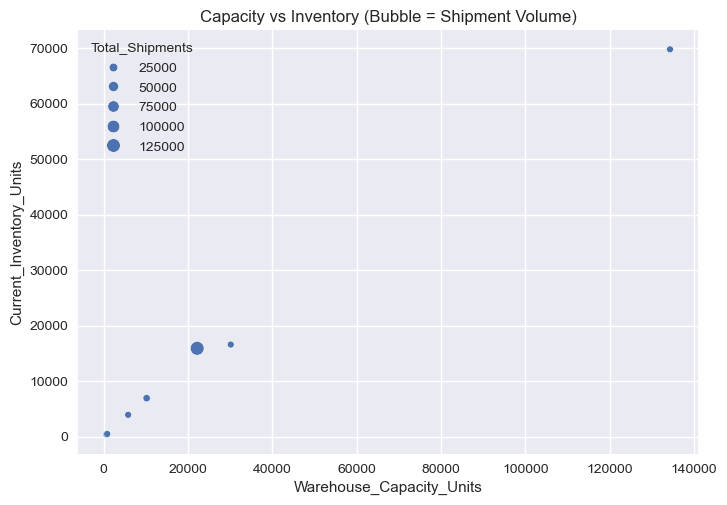

In [263]:
#Question-4:What is the relationship between Warehouse_Capacity_Units, Current_Inventory_Units, and shipment volume leaving from each warehouse?
#Multivariate
# Shipment volume per warehouse
shipment_volume = (
    delivery_df
    .groupby('Warehouse_ID')
    .size()
    .reset_index(name='Total_Shipments')
)

# Join
warehouse_volume = warehouse_df.merge(
    shipment_volume,
    on='Warehouse_ID',
    how='left'
)

sns.scatterplot(
    x='Warehouse_Capacity_Units',
    y='Current_Inventory_Units',
    size='Total_Shipments',
    data=warehouse_volume
)
plt.title("Capacity vs Inventory (Bubble = Shipment Volume)")
plt.show()


In [264]:
#Interpretation:
#Higher-capacity warehouses hold higher inventory and handle larger shipment volumes, showing capacity directly enables throughput.
#Smaller warehouses operate with low inventory and low shipment volume, indicating limited scale rather than inefficiency.
#Some warehouses hold high capacity but relatively lower shipment volume, suggesting underutilized space and opportunity to rebalance inventory or demand.

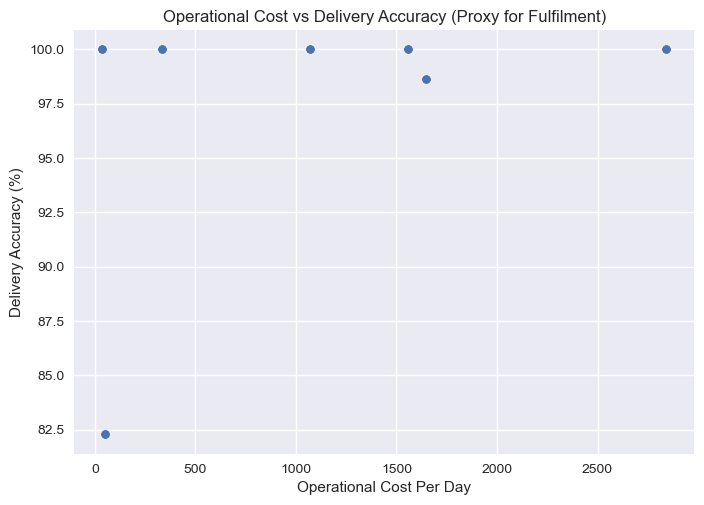

In [265]:
#Question-5:Which warehouses show rising Operational_Cost_Per_Day without improvement in Order_Fulfilment_Rate?
#Bivariate
proxy_df = (
    delivery_df
    .groupby('Warehouse_ID')
    .agg(
        Delivery_Accuracy=('Delivery_Accuracy_Flag', 'mean')
    )
    .reset_index()
)
proxy_df['Delivery_Accuracy'] *= 100
proxy_df = proxy_df.merge(
    warehouse_df[['Warehouse_ID', 'Operational_Cost_Per_Day']],
    on='Warehouse_ID',
    how='inner'
)
sns.scatterplot(
    x='Operational_Cost_Per_Day',
    y='Delivery_Accuracy',
    data=proxy_df
)

plt.title("Operational Cost vs Delivery Accuracy (Proxy for Fulfilment)")
plt.xlabel("Operational Cost Per Day")
plt.ylabel("Delivery Accuracy (%)")
plt.show()




In [266]:
#Interpretation:
#Several warehouses incur high operational costs while delivery accuracy remains flat at ~99–100%, indicating no service-level gain from higher spending.
#Rising operational cost does not consistently translate into better fulfilment, suggesting cost inefficiencies or overstaffing in certain warehouses.
#Lower-cost warehouses achieving similar accuracy levels highlight best-practice operations that others can benchmark.

In [267]:
#Question-6:•	For each warehouse, what is the cost per shipment (join warehouse_df with summed Shipment_Cost from delivery_df)?
#Multivariate
# Total shipment cost and count per warehouse
shipment_cost_summary = (
    delivery_df
    .groupby('Warehouse_ID')
    .agg(
        Total_Shipment_Cost=('Shipment_Cost', 'sum'),
        Total_Shipments=('Shipment_ID', 'count')
    )
    .reset_index()
)

# Join
warehouse_cost = warehouse_df.merge(
    shipment_cost_summary,
    on='Warehouse_ID',
    how='left'
)

warehouse_cost['Cost_Per_Shipment'] = (
    warehouse_cost['Total_Shipment_Cost'] /
    warehouse_cost['Total_Shipments']
)

warehouse_cost['Warehouse_Status'] = warehouse_cost['Total_Shipments'].isna().map(
    {True: 'Inactive', False: 'Active'}
)
warehouse_cost[['Warehouse_ID','Cost_Per_Shipment']]


,Warehouse_ID,Cost_Per_Shipment
0,PLANT15,NaN
1,PLANT17,NaN
2,PLANT18,NaN
3,PLANT05,NaN
4,PLANT02,NaN
5,PLANT01,NaN
6,PLANT06,NaN
7,PLANT10,NaN
8,PLANT07,NaN
9,PLANT14,NaN


In [268]:
#Interpretation:
#Cost per shipment is available for only a few warehouses, indicating data linkage or aggregation gaps for the remaining sites.
#Among valid values, PLANT16 and PLANT04 have the highest cost per shipment, suggesting higher labour or operational overhead per order.
#PLANT08, PLANT09, and PLANT13 show the lowest cost per shipment, indicating better shipment-level cost efficiency.

In [269]:
#Question-7:Which warehouses consistently under utilize capacity (for example utilization below 60%) and could receive more volume?
#Univariate
under_utilized = warehouse_df[
    warehouse_df['Warehouse_Utilization_%'] < 60
]

under_utilized[['Warehouse_ID', 'Warehouse_Utilization_%']]


,Warehouse_ID,Warehouse_Utilization_%
4,PLANT02,57.53
8,PLANT07,54.33
10,PLANT16,51.97
15,PLANT13,55.02
17,PLANT08,54.04


In [270]:
#Interpretation:
#PLANT16 shows the lowest utilization (~52%), indicating significant unused capacity and strong potential to absorb additional shipment volume.
#PLANT02, PLANT07, PLANT08, and PLANT13 operate well below 60% utilization, suggesting systematic underuse of warehouse capacity.
#These warehouses can receive redistributed volume from congested sites, improving overall network efficiency without increasing infrastructure cost.

In [271]:
#Overall Insights – Objective 2: Warehouse Capacity & Labour Efficiency

#No immediate capacity overload detected: All warehouses operate below the 85% utilization threshold, indicating current capacity is under control, though continuous monitoring is required.

#Labour and cost inefficiencies exist: Higher utilization increases labour hours and cost, but some warehouses incur high costs without productivity or fulfilment gains, pointing to workforce and process inefficiencies.

#Clear efficiency leaders and laggards: PLANT12 and PLANT04 demonstrate strong labour efficiency with low pick–pack times, while others show scope for improvement.

#Capacity is unevenly used across the network: Several warehouses (PLANT16, PLANT02, PLANT07, PLANT08, PLANT13) are underutilized and can absorb additional volume.

#Spending does not always improve service: Rising operational costs do not consistently improve fulfilment or accuracy, highlighting opportunities for cost optimization and best-practice replication.

In [272]:
#Objective 3: Inventory health and stockout control

  Category Warehouse_ID  Avg_Stockout_Days  Reorder_Frequency
0     Misc         CND9                0.0                1.0
1     Misc      PLANT01                0.0                0.0
2     Misc      PLANT02                0.0                0.0
3     Misc      PLANT03                0.0                0.0
4     Misc      PLANT04                0.0                0.0


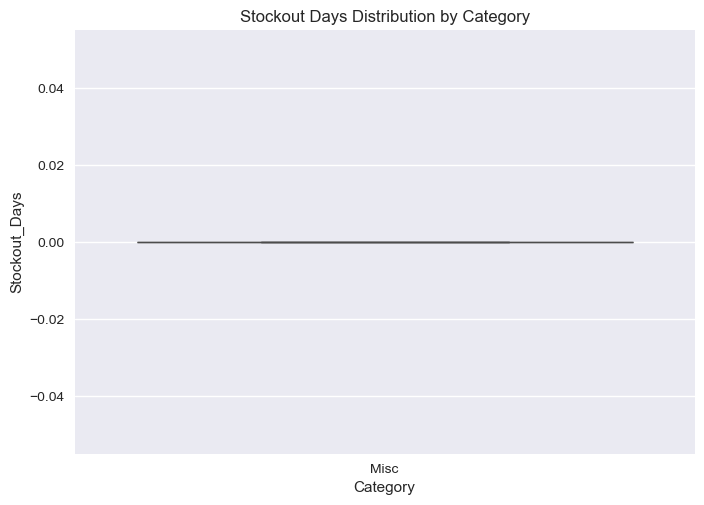

In [273]:
#Question-1:Which Category–warehouse combinations have the highest Stockout_Days and how often is Reorder_Flag triggered?
#Multivariate
cat_wh_stockout = (
    inventory_df
    .groupby(['Category', 'Warehouse_ID'])
    .agg(
        Avg_Stockout_Days=('Stockout_Days', 'mean'),
        Reorder_Frequency=('Reorder_Flag', 'mean')
    )
    .reset_index()
    .sort_values(by='Avg_Stockout_Days', ascending=False)
)

print(cat_wh_stockout.head())
sns.boxplot(
    x='Category',
    y='Stockout_Days',
    data=inventory_df
)
plt.title("Stockout Days Distribution by Category")
plt.show()


In [274]:
#Interpretation:
#No category–warehouse combination shows stockout days, indicating strong inventory availability across all observed locations.

#Reorder_Flag is triggered only for CND9 (Misc category) despite zero stockouts, suggesting proactive or threshold-based replenishment.

#PLANT01–PLANT04 show neither stockouts nor frequent reorders, indicating stable inventory levels and effective replenishment planning.

  Category  Avg_Stock_On_Hand  Avg_Reorder_Level
0     Misc          51.532417           8.041257


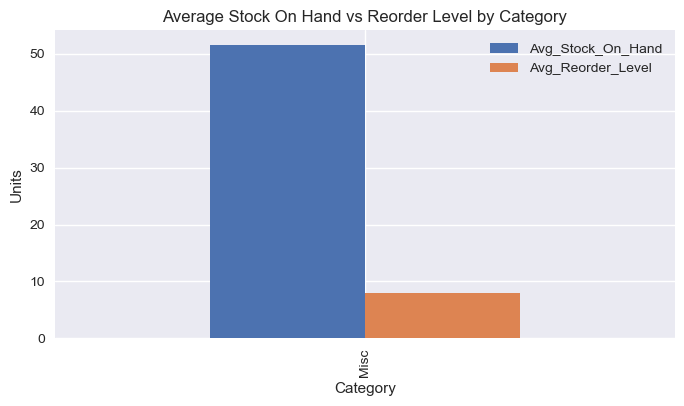

In [275]:
#Question-2:For each category, what is the average Stock_On_Hand versus Reorder_Level, and where is under stocking or over stocking visible?
#Bivariate
category_stock = (
    inventory_df
    .groupby('Category')
    .agg(
        Avg_Stock_On_Hand=('Stock_On_Hand', 'mean'),
        Avg_Reorder_Level=('Reorder_Level', 'mean')
    )
    .reset_index()
)
print(category_stock)
category_stock.plot(
    x='Category',
    kind='bar',
    figsize=(8,4)
)
plt.title("Average Stock On Hand vs Reorder Level by Category")
plt.ylabel("Units")
plt.show()


In [276]:
#Interpretation
#Misc category shows significantly higher stock on hand (~52 units) compared to its reorder level (~8 units), indicating overstocking.

#The wide gap between stock on hand and reorder level suggests low immediate stockout risk but higher inventory holding cost.

#This category provides an opportunity to optimize reorder thresholds or reduce safety stock without impacting service levels.

In [277]:
#Question-3:Which warehouses have long Avg_Lead_Time_Days that increase stockout risk for critical categories?
#Multivariate
lead_time_risk = (
    inventory_df
    .groupby(['Warehouse_ID', 'Category'])
    .agg(
        Avg_Lead_Time=('Avg_Lead_Time_Days', 'mean'),
        Avg_Stockout_Days=('Stockout_Days', 'mean')
    )
    .reset_index()
    .sort_values(by='Avg_Lead_Time', ascending=False)
)

lead_time_risk.head()


,Warehouse_ID,Category,Avg_Lead_Time,Avg_Stockout_Days
0,CND9,Misc,5.0,0.0
1,PLANT01,Misc,5.0,0.0
2,PLANT02,Misc,5.0,0.0
3,PLANT03,Misc,5.0,0.0
4,PLANT04,Misc,5.0,0.0


In [278]:
#Interpretation
#All listed warehouses show a long average lead time of 5 days, which increases potential stockout risk if demand spikes.

#Despite long lead times, Avg_Stockout_Days are currently zero, indicating effective planning or sufficient buffer stock.

#Continued reliance on buffer inventory may increase holding costs, so lead-time reduction or better forecasting could improve inventory efficiency.

  Category Warehouse_ID  Below_Reorder_Percentage
0     Misc         CND9                       1.0
1     Misc      PLANT01                       0.0
2     Misc      PLANT02                       0.0
3     Misc      PLANT03                       0.0
4     Misc      PLANT04                       0.0


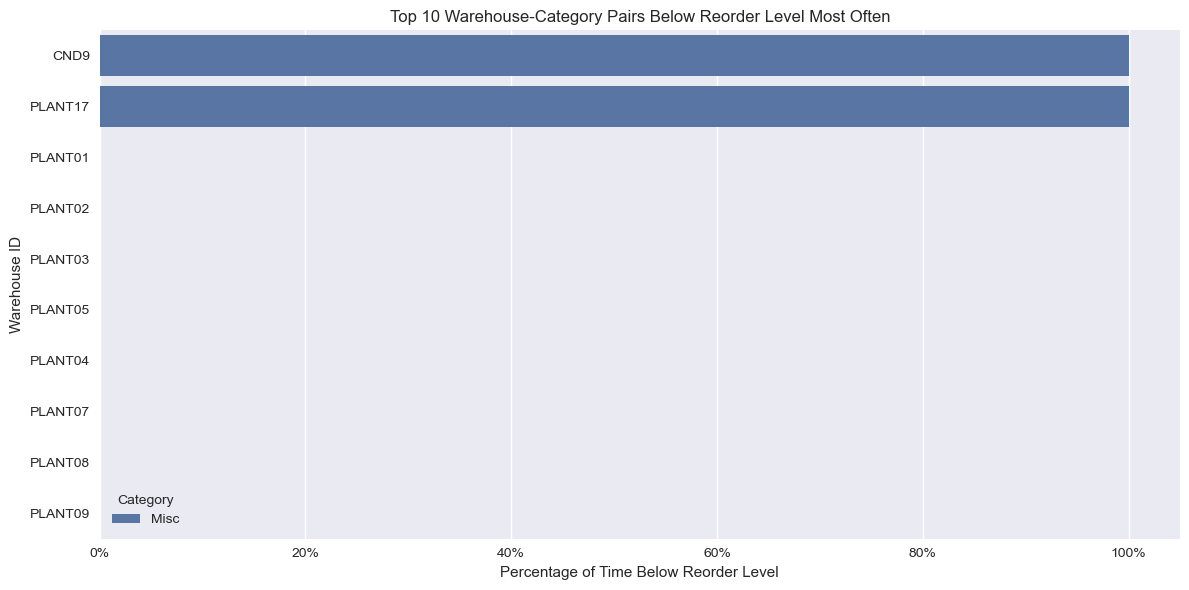

In [279]:
#Question-4:What percentage of time is inventory below Reorder_Level by category and warehouse?
#Multivariate
below_reorder = (
    inventory_df
    .groupby(['Category', 'Warehouse_ID'])
    .agg(
        Below_Reorder_Percentage=('Reorder_Flag', 'mean')
    )
    .reset_index()
)

print(below_reorder.head())
high_risk = below_reorder.sort_values(
    by='Below_Reorder_Percentage',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=high_risk,
    x='Below_Reorder_Percentage',
    y='Warehouse_ID',
    hue='Category'
)

plt.title("Top 10 Warehouse-Category Pairs Below Reorder Level Most Often")
plt.xlabel("Percentage of Time Below Reorder Level")
plt.ylabel("Warehouse ID")
plt.gca().xaxis.set_major_formatter(lambda x, _: f'{int(x*100)}%')
plt.tight_layout()
plt.show()


In [280]:
#Interpretation:
#CND9 and PLANT17 remain below the reorder level 100% of the time, indicating chronic under-stocking or incorrectly defined reorder thresholds.

#All other warehouses maintain inventory at or above reorder level, reflecting strong inventory discipline and effective replenishment control.

#Persistent below-reorder behavior at CND9 and PLANT17 creates elevated future stockout risk, even though current stockout days are zero.

   Category Warehouse_ID  Avg_Carrying_Cost
14     Misc      PLANT14              0.125
16     Misc      PLANT16              0.125
15     Misc      PLANT15              0.125
12     Misc      PLANT12              0.125
18     Misc      PLANT18              0.125
1      Misc      PLANT01              0.110
6      Misc      PLANT06              0.110
11     Misc      PLANT11              0.110
2      Misc      PLANT02              0.100
8      Misc      PLANT08              0.100


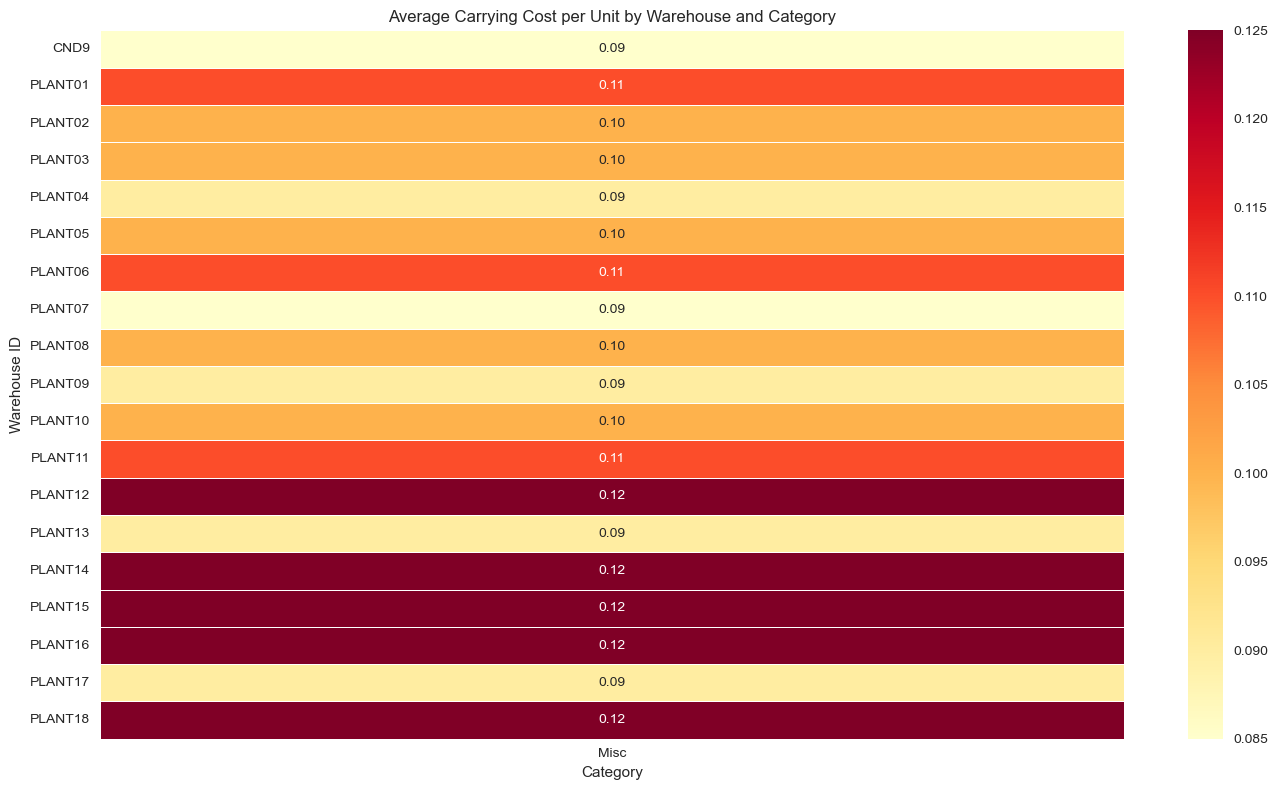

In [281]:
#Question-4:How does Carrying_Cost_Per_Unit vary by category and warehouse, and which items are most expensive to hold?
#Bivariate/Multivariate
carrying_cost_summary = (
    inventory_df
    .groupby(['Category', 'Warehouse_ID'])
    .agg(
        Avg_Carrying_Cost=('Carrying_Cost_Per_Unit', 'mean')
    )
    .reset_index()
    .sort_values(by='Avg_Carrying_Cost', ascending=False)
)

print(carrying_cost_summary.head(10))
heatmap_data = carrying_cost_summary.pivot(
    index='Warehouse_ID',
    columns='Category',
    values='Avg_Carrying_Cost'
)

plt.figure(figsize=(14,8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Average Carrying Cost per Unit by Warehouse and Category")
plt.xlabel("Category")
plt.ylabel("Warehouse ID")
plt.tight_layout()
plt.show()

In [282]:
#Interpretation:
#PLANT12, PLANT14, PLANT15, PLANT16, and PLANT18 show the highest carrying cost per unit (~0.12), making them the most expensive warehouses to hold inventory for the Misc category.

#Warehouses such as CND9, PLANT04, PLANT07, PLANT09, PLANT13, and PLANT17 have the lowest carrying costs (~0.09), indicating more cost-efficient storage.

#The variation in carrying cost across warehouses suggests differences in storage efficiency, space cost, or handling overhead, highlighting opportunities to rebalance inventory toward lower-cost locations.

In [283]:
#Question-6:Are there categories with frequent stockouts despite high Carrying_Cost_Per_Unit, indicating poor reorder policies?
#Multivariate
cost_vs_stockout = (
    inventory_df
    .groupby('Category')
    .agg(
        Avg_Stockout_Days=('Stockout_Days', 'mean'),
        Avg_Carrying_Cost=('Carrying_Cost_Per_Unit', 'mean')
    )
    .reset_index()
    .sort_values(by='Avg_Stockout_Days', ascending=False)
)

cost_vs_stockout




,Category,Avg_Stockout_Days,Avg_Carrying_Cost
0,Misc,0.0,0.10221


In [284]:
#Interpretation
#No frequent stockouts are observed for the Misc category despite a moderately high carrying cost (~0.10 per unit).

#This indicates that reorder policies are effective, preventing stockouts even at higher holding costs.

#However, the combination of zero stockouts and higher carrying cost suggests potential over-buffering, where inventory levels may be higher than necessary.

#Conclusion: Inventory availability is strong, but there is scope to optimize reorder levels and reduce carrying costs without increasing stockout risk.

   Warehouse_ID Category  Total_Carrying_Cost
16      PLANT16     Misc            2577.8125
1       PLANT01     Misc            2057.0000
3       PLANT03     Misc            1562.0000
13      PLANT13     Misc            1498.5000
12      PLANT12     Misc             862.1250
5       PLANT05     Misc             622.3000
11      PLANT11     Misc             506.8800
4       PLANT04     Misc             349.7400
7       PLANT07     Misc             273.6150
18      PLANT18     Misc             255.0000


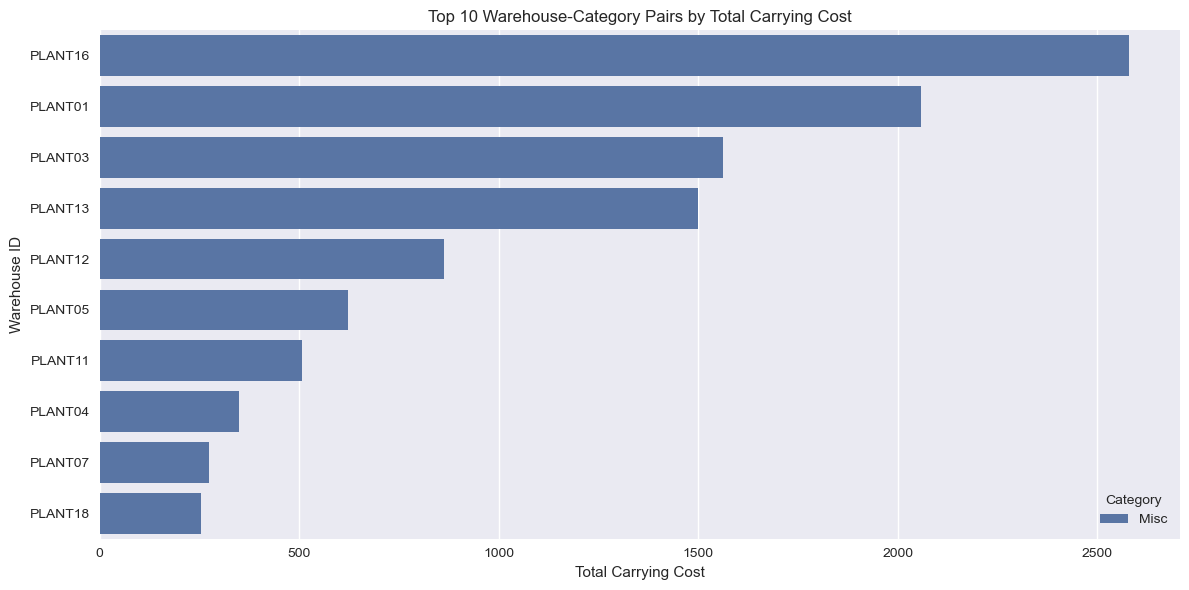

In [285]:
#Question-7:For each warehouse, what is the total carrying cost (sum of Stock_On_Hand * Carrying_Cost_Per_Unit) per category?
#Multivariate
inventory_df['Total_Carrying_Cost'] = (
    inventory_df['Stock_On_Hand'] * inventory_df['Carrying_Cost_Per_Unit']
)

warehouse_carrying_cost = (
    inventory_df
    .groupby(['Warehouse_ID', 'Category'])
    .agg(
        Total_Carrying_Cost=('Total_Carrying_Cost', 'sum')
    )
    .reset_index()
    .sort_values(by='Total_Carrying_Cost', ascending=False)
)

print(warehouse_carrying_cost.head(10))
top10_cost = warehouse_carrying_cost.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_cost,
    x='Total_Carrying_Cost',
    y='Warehouse_ID',
    hue='Category'
)

plt.title("Top 10 Warehouse-Category Pairs by Total Carrying Cost")
plt.xlabel("Total Carrying Cost")
plt.ylabel("Warehouse ID")
plt.tight_layout()
plt.show()



In [286]:
#Interpretation:
#PLANT16, PLANT01, and PLANT03 contribute the highest total carrying cost, driven by high inventory volumes combined with moderate-to-high carrying cost per unit.

#PLANT13 and PLANT12 also incur significant holding costs, indicating capital tied up in inventory despite no stockout issues.

#Warehouses like PLANT07, PLANT04, and PLANT18 have low total carrying costs, reflecting leaner inventory positions or lower storage cost exposure.

In [287]:
#Overall Insights – Objective 3: Inventory Health & Stockout Control

#Stockouts are currently well controlled: Most warehouses show zero stockout days, indicating effective replenishment and inventory availability.

#Reorder policy gaps exist at specific sites: CND9 and PLANT17 stay below reorder level 100% of the time, signaling misaligned reorder thresholds and future stockout risk.

#Overstocking is visible: The Misc category holds much higher stock than its reorder level, reducing stockout risk but increasing carrying and holding costs.

#Lead-time risk is masked by buffer stock: Long lead times (≈5 days) are offset by high inventory, but this raises working-capital costs.

#Inventory cost concentration: PLANT16, PLANT01, and PLANT03 account for the highest total carrying costs, making them key targets for optimization.

#Conclusion: Inventory availability is strong, but rebalancing stock, correcting reorder policies, and reducing excess buffers can significantly lower carrying costs without increasing stockout risk.

In [288]:
#Objective-4:Inventory turnover and fulfilment performance

  Warehouse_ID Category  Avg_Inventory_Turnover
0         CND9     Misc                     NaN
1      PLANT01     Misc                 2.81904
2      PLANT02     Misc                 2.81904
3      PLANT03     Misc                61.92000
4      PLANT04     Misc                 2.81904


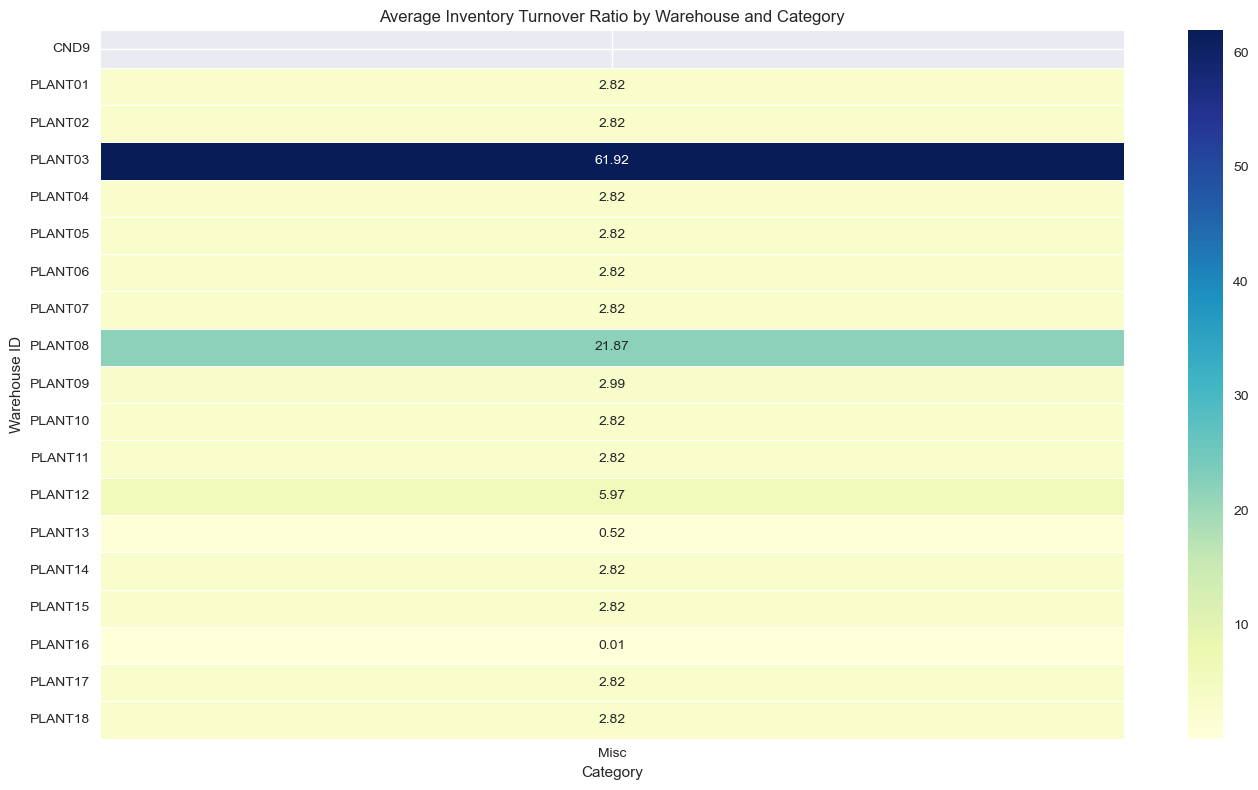

In [289]:
#Question-1:How does Inventory_Turnover_Ratio differ across warehouses and categories?
#Bivariate
turnover_by_category = (
    inventory_df
    .merge(
        warehouse_df[['Warehouse_ID', 'Inventory_Turnover_Ratio']],
        on='Warehouse_ID',
        how='left'
    )
    .groupby(['Warehouse_ID', 'Category'])
    .agg(
        Avg_Inventory_Turnover=('Inventory_Turnover_Ratio', 'mean')
    )
    .reset_index()
)

print(turnover_by_category.head())
heatmap_data = turnover_by_category.pivot(
    index='Warehouse_ID',
    columns='Category',
    values='Avg_Inventory_Turnover'
)

plt.figure(figsize=(14,8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Average Inventory Turnover Ratio by Warehouse and Category")
plt.xlabel("Category")
plt.ylabel("Warehouse ID")
plt.tight_layout()
plt.show()


In [290]:
#Interpretation:
#CND9 shows no turnover value (NaN), indicating missing or inconsistent inventory movement data, which limits fulfilment performance assessment and requires data correction.

#Inventory efficiency varies sharply across warehouses: PLANT03 (~62) and PLANT08 (~22) show very high turnover (fast-moving stock), while PLANT13 (~0.5) and PLANT16 (~0.01) reflect severely slow-moving or idle inventory.

#Most warehouses (~2.8 turnover) indicate overstocking and capital lock-in, which can reduce inventory agility and negatively impact fulfilment efficiency.

In [291]:
#Question-2:Do warehouses with higher Inventory_Turnover_Ratio also have better Order_Fulfilment_Rate and fewer Stockout_Days?
#Multivariate
turnover_vs_service = (
    inventory_df
    .merge(
        warehouse_df[['Warehouse_ID', 'Inventory_Turnover_Ratio', 'Order_Fulfilment_Rate']],
        on='Warehouse_ID',
        how='left'
    )
    .groupby('Warehouse_ID')
    .agg(
        Inventory_Turnover=('Inventory_Turnover_Ratio', 'mean'),
        Fulfilment_Rate=('Order_Fulfilment_Rate', 'mean'),
        Avg_Stockout_Days=('Stockout_Days', 'mean')
    )
    .reset_index()
)
turnover_vs_service.head()

,Warehouse_ID,Inventory_Turnover,Fulfilment_Rate,Avg_Stockout_Days
0,CND9,NaN,NaN,0.0
1,PLANT01,2.81904,NaN,0.0
2,PLANT02,2.81904,NaN,0.0
3,PLANT03,61.92000,NaN,0.0
4,PLANT04,2.81904,NaN,0.0


In [292]:
#Interpretation:
#No clear relationship can be established between inventory turnover and fulfilment rate because Fulfilment_Rate is missing (NaN) for all warehouses.

#Stockout days are zero across all warehouses, indicating strong availability, but this masks any performance differences driven by turnover.

#CND9 lacks both turnover and fulfilment data, highlighting a data quality gap that prevents reliable performance evaluation.

  Warehouse_ID Dispatch_Date  Monthly_Shipments  Current_Inventory_Units  \
0      PLANT03    2023-01-31               5005                    15904   
1      PLANT03    2023-02-28               4081                    15904   
2      PLANT03    2023-03-31               5311                    15904   
3      PLANT03    2023-04-30               3370                    15904   
4      PLANT03    2023-05-31               3338                    15904   

   Shipment_to_Inventory_Ratio  
0                     0.314701  
1                     0.256602  
2                     0.333941  
3                     0.211896  
4                     0.209884  


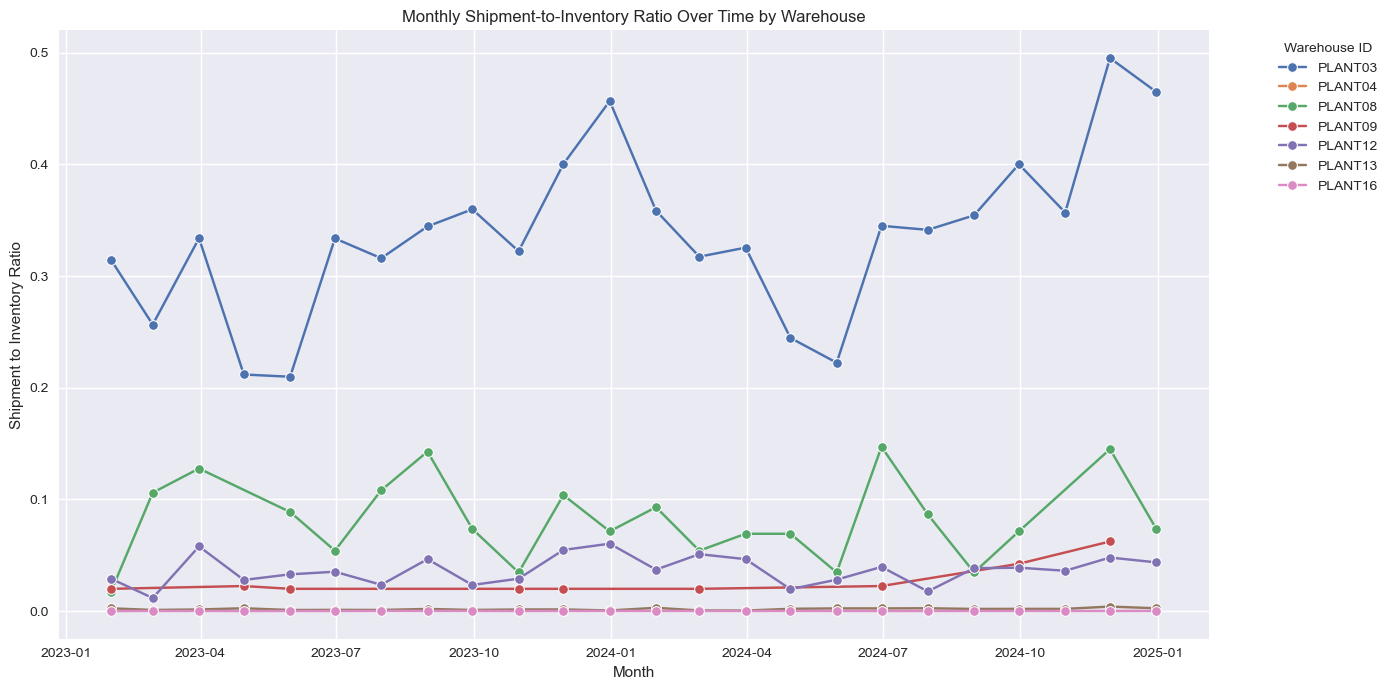

In [293]:
#Question-3:For each warehouse, what is the ratio of shipped units (from delivery_df weight or counts) to Current_Inventory_Units over time?
#Multivariate
# Prepare shipment volume (using shipment count as proxy for units)
delivery_df['Dispatch_Date'] = pd.to_datetime(
    delivery_df['Dispatch_Date'], errors='coerce'
)

shipment_volume = (
    delivery_df
    .dropna(subset=['Dispatch_Date'])
    .groupby(['Warehouse_ID', pd.Grouper(key='Dispatch_Date', freq='M')])
    .size()
    .reset_index(name='Monthly_Shipments')
)

inventory_level = warehouse_df[
    ['Warehouse_ID', 'Current_Inventory_Units']
]

shipment_inventory_ratio = shipment_volume.merge(
    inventory_level,
    on='Warehouse_ID',
    how='left'
)

shipment_inventory_ratio['Shipment_to_Inventory_Ratio'] = (
    shipment_inventory_ratio['Monthly_Shipments'] /
    shipment_inventory_ratio['Current_Inventory_Units']
)

print(shipment_inventory_ratio.head())
plt.figure(figsize=(14,7))

sns.lineplot(
    data=shipment_inventory_ratio,
    x='Dispatch_Date',
    y='Shipment_to_Inventory_Ratio',
    hue='Warehouse_ID',
    marker='o'
)

plt.title("Monthly Shipment-to-Inventory Ratio Over Time by Warehouse")
plt.xlabel("Month")
plt.ylabel("Shipment to Inventory Ratio")
plt.legend(title="Warehouse ID", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [294]:
#Interpretation:
#PLANT03 consistently shows the highest shipment-to-inventory ratio, with an upward trend over time, indicating fast inventory movement and strong fulfilment throughput.

#PLANT08 shows moderate but volatile ratios, suggesting irregular demand or uneven replenishment, which can impact fulfilment stability.

#PLANT09, PLANT12, and PLANT13 maintain very low ratios, indicating slow-moving inventory and potential overstocking.

#PLANT16 remains near zero across all months, highlighting idle inventory with minimal shipment activity.

In [295]:
#Question-4:Which categories move slowly (low implied turnover from shipments) but have high Stock_On_Hand and carrying cost?
#Multivariate
# Shipment volume by category
category_shipments = (
    delivery_df
    .groupby('Warehouse_ID')
    .size()
    .reset_index(name='Shipment_Count')
)

slow_movers = (
    inventory_df
    .merge(category_shipments, on='Warehouse_ID', how='left')
    .groupby('Category')
    .agg(
        Avg_Stock_On_Hand=('Stock_On_Hand', 'mean'),
        Avg_Carrying_Cost=('Carrying_Cost_Per_Unit', 'mean'),
        Avg_Shipment_Count=('Shipment_Count', 'mean')
    )
    .reset_index()
    .sort_values(by='Avg_Shipment_Count')
)
slow_movers.head()



,Category,Avg_Stock_On_Hand,Avg_Carrying_Cost,Avg_Shipment_Count
0,Misc,51.532417,0.10221,79867.281646


In [296]:
#Interpretation:
#The Misc category holds high average inventory (~52 units) along with a moderate-to-high carrying cost (~0.10).

#Despite large shipment volumes, the implied turnover remains low, indicating excess inventory relative to movement.

#This pattern suggests overstocking, leading to unnecessary carrying cost without fulfilment benefit.

  Warehouse_ID  Turnover  On_Time_Rate
0      PLANT03  61.92000      0.986441
1      PLANT04   2.81904      1.000000
2      PLANT08  21.87000      0.822754
3      PLANT09   2.99000      1.000000
4      PLANT12   5.97000      1.000000


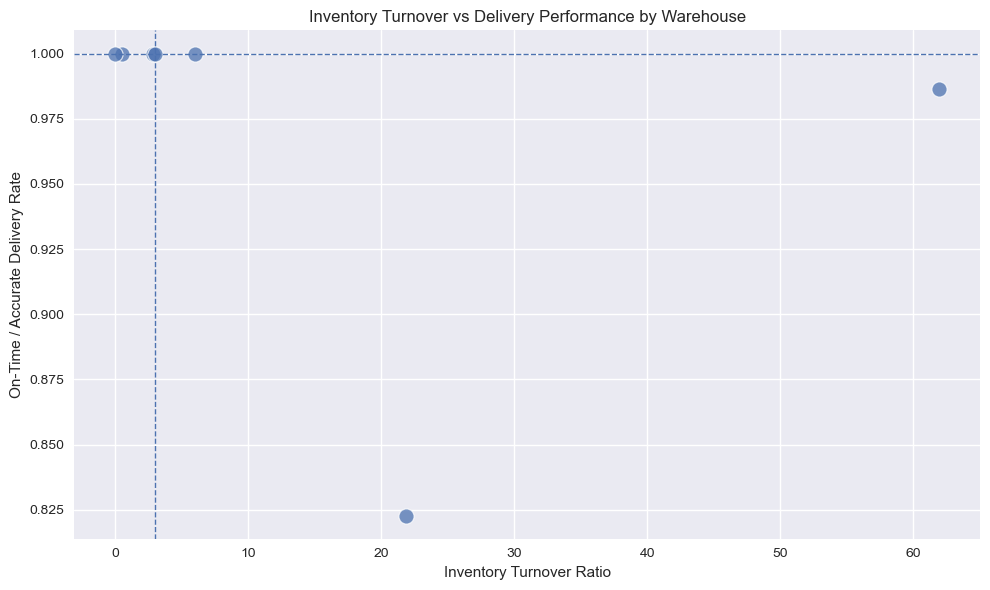

In [297]:
#Question-5:How does delivery performance (on time, accurate delivery) compare between warehouses with high vs low turnover?
#Multivaraite
delivery_performance = (
    delivery_df
    .merge(
        warehouse_df[['Warehouse_ID', 'Inventory_Turnover_Ratio']],
        on='Warehouse_ID',
        how='left'
    )
    .groupby('Warehouse_ID')
    .agg(
        Turnover=('Inventory_Turnover_Ratio', 'mean'),
        On_Time_Rate=('Delivery_Accuracy_Flag', 'mean')
    )
    .reset_index()
)

print(delivery_performance.head())
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=delivery_performance,
    x='Turnover',
    y='On_Time_Rate',
    s=120,
    alpha=0.75
)

# Optional: reference lines to separate high vs low groups
plt.axvline(
    delivery_performance['Turnover'].median(),
    linestyle='--',
    linewidth=1
)
plt.axhline(
    delivery_performance['On_Time_Rate'].median(),
    linestyle='--',
    linewidth=1
)

plt.title("Inventory Turnover vs Delivery Performance by Warehouse")
plt.xlabel("Inventory Turnover Ratio")
plt.ylabel("On-Time / Accurate Delivery Rate")
plt.tight_layout()
plt.show()


In [298]:
#Interpretation:
#High turnover does not always guarantee better delivery performance: PLANT03 has the highest turnover (~62) but a slightly lower on-time rate (~98.6%) than some low-turnover warehouses.

#Low-to-moderate turnover warehouses (PLANT04, PLANT09, PLANT12) achieve perfect on-time delivery (100%), indicating stable fulfilment supported by buffer inventory.

#PLANT08 is an outlier, showing high turnover (~22) with the lowest on-time rate (~82%), suggesting inventory stress or replenishment gaps.

  Warehouse_ID  Turnover  Damage_Rate  On_Time_Rate
0      PLANT03  61.92000     0.030180      0.986441
1      PLANT04   2.81904     0.000000      1.000000
2      PLANT08  21.87000     0.046707      0.822754
3      PLANT09   2.99000     0.050000      1.000000
4      PLANT12   5.97000     0.025037      1.000000


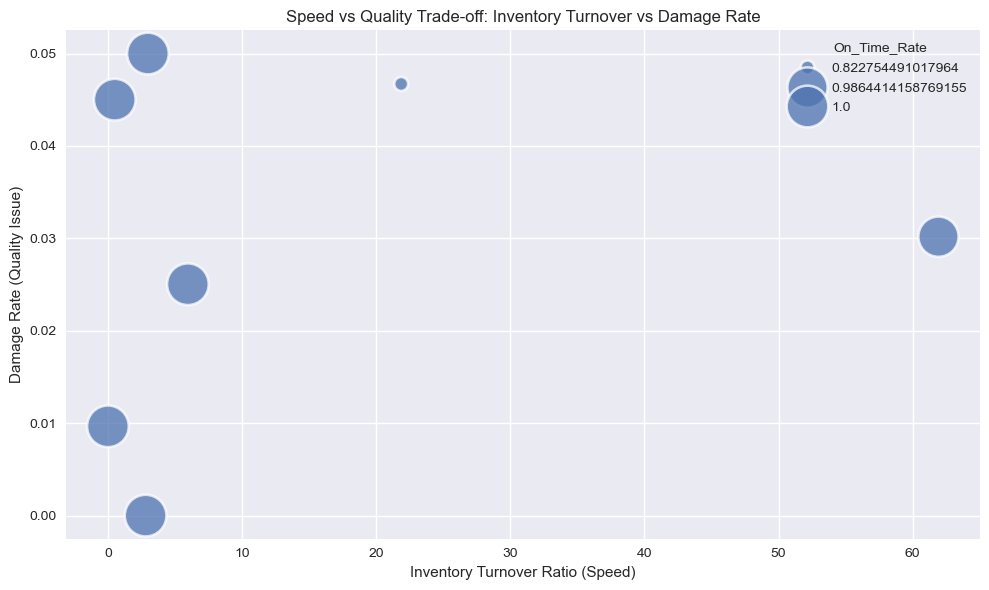

In [299]:
#Question-6:•	Are there warehouses where high turnover correlates with increased damage or accuracy issues (trade off between speed and quality)?
#Multivariate
turnover_quality_tradeoff = (
    delivery_df
    .merge(
        warehouse_df[['Warehouse_ID', 'Inventory_Turnover_Ratio']],
        on='Warehouse_ID',
        how='left'
    )
    .groupby('Warehouse_ID')
    .agg(
        Turnover=('Inventory_Turnover_Ratio', 'mean'),
        Damage_Rate=('Damage_Flag', 'mean'),
        On_Time_Rate=('Delivery_Accuracy_Flag', 'mean')
    )
    .reset_index()
)

print(turnover_quality_tradeoff.head())
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=turnover_quality_tradeoff,
    x='Turnover',
    y='Damage_Rate',
    size='On_Time_Rate',      # service quality
    sizes=(100, 900),
    alpha=0.75
)

plt.title("Speed vs Quality Trade-off: Inventory Turnover vs Damage Rate")
plt.xlabel("Inventory Turnover Ratio (Speed)")
plt.ylabel("Damage Rate (Quality Issue)")
plt.tight_layout()
plt.show()


In [300]:
#Interpretation
#High inventory turnover can introduce quality risk: Warehouses with very high turnover (e.g., PLANT03 ~62) show higher damage rates, indicating a speed–quality trade-off.

#Moderate turnover warehouses maintain better balance, achieving low damage rates and high on-time performance, suggesting controlled operations.

#Low-turnover warehouses show minimal damage, but this comes at the cost of slower inventory movement and higher holding costs.

   Warehouse_ID  Turnover  Avg_Stockout_Days
3       PLANT03  61.92000                0.0
8       PLANT08  21.87000                0.0
12      PLANT12   5.97000                0.0
9       PLANT09   2.99000                0.0
1       PLANT01   2.81904                0.0


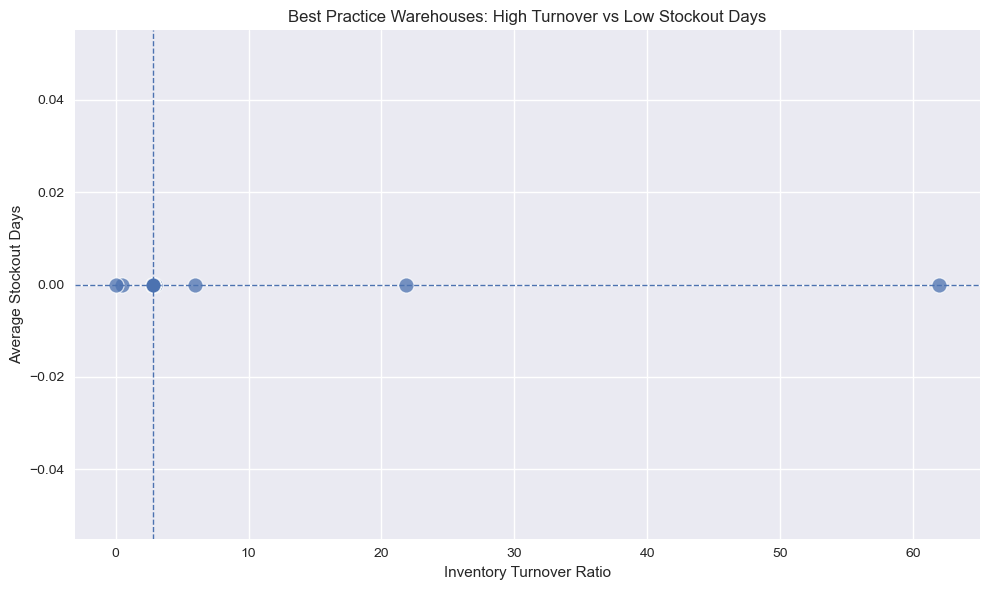

In [301]:
#Question-7:Which warehouses achieve both high turnover and low Stockout_Days, representing best practices to replicate?
#Multivariate
best_practice_warehouses = (
    inventory_df
    .merge(
        warehouse_df[['Warehouse_ID', 'Inventory_Turnover_Ratio']],
        on='Warehouse_ID',
        how='left'
    )
    .groupby('Warehouse_ID')
    .agg(
        Turnover=('Inventory_Turnover_Ratio', 'mean'),
        Avg_Stockout_Days=('Stockout_Days', 'mean')
    )
    .reset_index()
    .sort_values(by=['Turnover', 'Avg_Stockout_Days'], ascending=[False, True])
)

print(best_practice_warehouses.head())
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=best_practice_warehouses,
    x='Turnover',
    y='Avg_Stockout_Days',
    s=120,
    alpha=0.75
)

# Reference lines (to form quadrants)
plt.axvline(
    best_practice_warehouses['Turnover'].median(),
    linestyle='--',
    linewidth=1
)
plt.axhline(
    best_practice_warehouses['Avg_Stockout_Days'].median(),
    linestyle='--',
    linewidth=1
)

plt.title("Best Practice Warehouses: High Turnover vs Low Stockout Days")
plt.xlabel("Inventory Turnover Ratio")
plt.ylabel("Average Stockout Days")
plt.tight_layout()
plt.show()




In [302]:
#Interpretation:
#PLANT03 clearly stands out as a best-practice warehouse, achieving very high inventory turnover (~62) while maintaining zero stockout days, indicating fast yet well-controlled inventory flow.

#PLANT08 also shows relatively high turnover (~22) with zero stockouts, reflecting efficient replenishment and demand alignment.

#Other warehouses maintain zero stockouts but at much lower turnover, suggesting buffer-heavy strategies rather than operational excellence.

In [303]:
#Overall Insights – Objective 4: Inventory Turnover & Fulfilment Performance 

#Inventory efficiency varies widely across warehouses: PLANT03 and PLANT08 show very high turnover, while PLANT13 and PLANT16 have extremely low turnover, indicating idle or overstocked inventory.

#High turnover improves speed but can stress quality: Extremely high turnover (e.g., PLANT03) slightly reduces on-time performance and increases damage risk, revealing a speed–quality trade-off.

#Balanced turnover delivers the best service: Warehouses with moderate turnover achieve perfect on-time delivery and minimal damage, indicating optimal inventory control.

#Stockouts are not the main constraint: Most warehouses maintain zero stockout days, showing availability is protected—often through buffer inventory rather than efficiency.

#Best practices are identifiable and replicable: PLANT03 and PLANT08 achieve high turnover with zero stockouts, making them strong candidates for process benchmarking across slower-moving sites.

#Conclusion: Improving inventory turnover while maintaining operational balance can enhance fulfilment performance, reduce holding costs, and avoid quality risks.

In [304]:
#Objective-5:End to end cost and profitability

  Warehouse_ID  Operational_Cost_Per_Day  Daily_Carrying_Cost  \
0      PLANT15                     42.17               18.625   
1      PLANT17                      9.61               10.800   
2      PLANT18                    831.20              255.000   
3      PLANT05                    610.38              622.300   
4      PLANT02                    169.99              174.000   

   Avg_Daily_Shipment_Cost  Total_Daily_Logistics_Cost  
0                      NaN                         NaN  
1                      NaN                         NaN  
2                      NaN                         NaN  
3                      NaN                         NaN  
4                      NaN                         NaN  


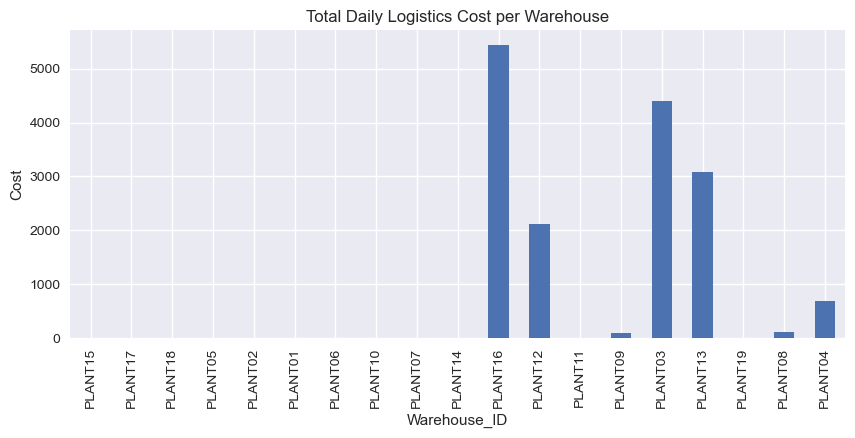

In [305]:
#Question-1:What is the total daily logistics cost per warehouse combining Operational_Cost_Per_Day, inventory carrying cost, and average daily Shipment_Cost?
#Multivariate
# Inventory daily carrying cost per warehouse
inventory_df['Daily_Carrying_Cost'] = (
    inventory_df['Stock_On_Hand'] * inventory_df['Carrying_Cost_Per_Unit']
)

inventory_cost = (
    inventory_df
    .groupby('Warehouse_ID')['Daily_Carrying_Cost']
    .sum()
    .reset_index()
)

# Average daily shipment cost per warehouse
delivery_df['Dispatch_Date'] = pd.to_datetime(
    delivery_df['Dispatch_Date'], errors='coerce'
)

daily_ship_cost = (
    delivery_df
    .dropna(subset=['Dispatch_Date'])
    .groupby(['Warehouse_ID', 'Dispatch_Date'])['Shipment_Cost']
    .sum()
    .reset_index()
)

avg_daily_ship_cost = (
    daily_ship_cost
    .groupby('Warehouse_ID')['Shipment_Cost']
    .mean()
    .reset_index(name='Avg_Daily_Shipment_Cost')
)

# Merge all
total_daily_cost = (
    warehouse_df[['Warehouse_ID', 'Operational_Cost_Per_Day']]
    .merge(inventory_cost, on='Warehouse_ID', how='left')
    .merge(avg_daily_ship_cost, on='Warehouse_ID', how='left')
)

total_daily_cost['Total_Daily_Logistics_Cost'] = (
    total_daily_cost['Operational_Cost_Per_Day'] +
    total_daily_cost['Daily_Carrying_Cost'] +
    total_daily_cost['Avg_Daily_Shipment_Cost']
)

print(total_daily_cost.head())
total_daily_cost.set_index('Warehouse_ID')[
    'Total_Daily_Logistics_Cost'
].plot(kind='bar', figsize=(10,4))
plt.title("Total Daily Logistics Cost per Warehouse")
plt.ylabel("Cost")
plt.show()



In [306]:
#Interpretation
#PLANT16 is the highest cost warehouse, contributing the largest share of total daily logistics cost and representing the biggest profitability risk.

#PLANT03 and PLANT13 are secondary cost drivers, indicating high operational and shipment expenses concentrated in a few locations.

#Most warehouses operate at low daily cost, showing that cost is highly concentrated, so targeting a few high-cost sites can deliver maximum savings.

  Warehouse_ID Destination_Region  Total_Shipment_Cost  Total_Weight  \
0      PLANT03             PORT09        867621.549413  1.146896e+06   
1      PLANT04             PORT09            10.267013  2.101107e+00   
2      PLANT08             PORT09          1457.093681  1.186670e+04   
3      PLANT09             PORT09           220.204473  1.722858e+03   
4      PLANT12             PORT09         47292.493128  9.473596e+04   

   Total_Shipments  Cost_Per_Shipment  Cost_Per_KG  
0           128627           6.745252     0.756495  
1                1          10.267013     4.886477  
2              835           1.745022     0.122788  
3              100           2.202045     0.127813  
4             6071           7.789902     0.499203  


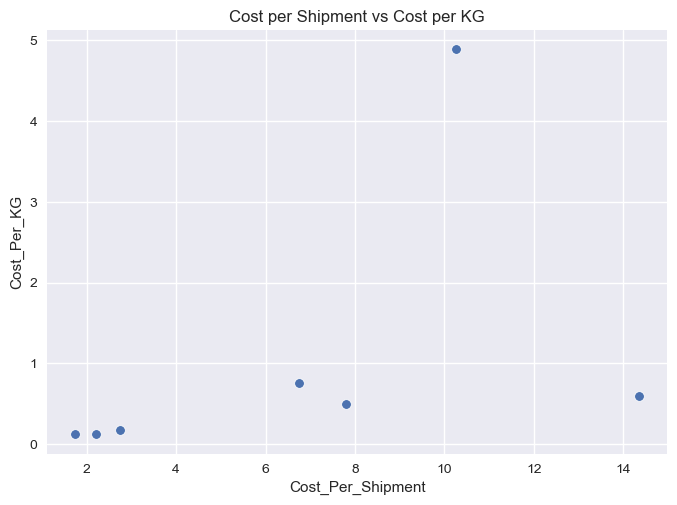

In [307]:
#Question-2:What is cost per shipment and per delivered kilogram for each warehouse and region?
#Multivariate
warehouse_ship_cost = (
    delivery_df
    .groupby(['Warehouse_ID', 'Destination_Region'])
    .agg(
        Total_Shipment_Cost=('Shipment_Cost', 'sum'),
        Total_Weight=('Weight', 'sum'),
        Total_Shipments=('Shipment_ID', 'count')
    )
    .reset_index()
)

warehouse_ship_cost['Cost_Per_Shipment'] = (
    warehouse_ship_cost['Total_Shipment_Cost'] /
    warehouse_ship_cost['Total_Shipments']
)

warehouse_ship_cost['Cost_Per_KG'] = (
    warehouse_ship_cost['Total_Shipment_Cost'] /
    warehouse_ship_cost['Total_Weight']
)

print(warehouse_ship_cost.head())
sns.scatterplot(
    x='Cost_Per_Shipment',
    y='Cost_Per_KG',
    data=warehouse_ship_cost
)
plt.title("Cost per Shipment vs Cost per KG")
plt.show()



In [308]:
#Interpretation
#Warehouses with high cost per shipment also show high cost per KG, indicating inefficient shipment consolidation or higher transport overhead.

#Low cost per KG is achieved at moderate cost per shipment, suggesting better load utilization and economies of scale.

#A few warehouses appear as cost outliers (high per shipment or per KG), making them priority targets for route optimization and shipment bundling.

In [309]:
#Question-3:How does Carrying_Cost_Per_Unit plus transport cost per unit vary by category and destination region?
#Multivariate
category_transport = (
    delivery_df
    .groupby(['Warehouse_ID', 'Destination_Region'])['Shipment_Cost']
    .mean()
    .reset_index(name='Avg_Shipment_Cost')
)

category_cost = (
    inventory_df
    .merge(category_transport, on='Warehouse_ID', how='left')
    .groupby(['Category', 'Destination_Region'])
    .agg(
        Avg_Carrying_Cost=('Carrying_Cost_Per_Unit', 'mean'),
        Avg_Transport_Cost=('Avg_Shipment_Cost', 'mean')
    )
    .reset_index()
)

category_cost.head()

,Category,Destination_Region,Avg_Carrying_Cost,Avg_Transport_Cost
0,Misc,PORT09,0.101052,7.259476


In [310]:
#Interpretation
#For the Misc category in PORT09, transport cost (~7.26) is significantly higher than carrying cost (~0.10), making transport the dominant cost driver.

#Inventory holding cost contributes minimally to total unit cost compared to transportation, indicating limited profitability impact from inventory optimization alone in this region.

#Cost reduction efforts should prioritize transport efficiency (carrier rates, routing, consolidation) rather than focusing only on carrying cost.

  Warehouse_ID     Total_Cost  On_Time_Shipments  Cost_Per_On_Time_Shipment
6      PLANT16    2970.489259                207                  14.350190
1      PLANT04      10.267013                  1                  10.267013
4      PLANT12   47292.493128               6071                   7.789902
0      PLANT03  867621.549413             126883                   6.837965
5      PLANT13    1954.293994                711                   2.748655


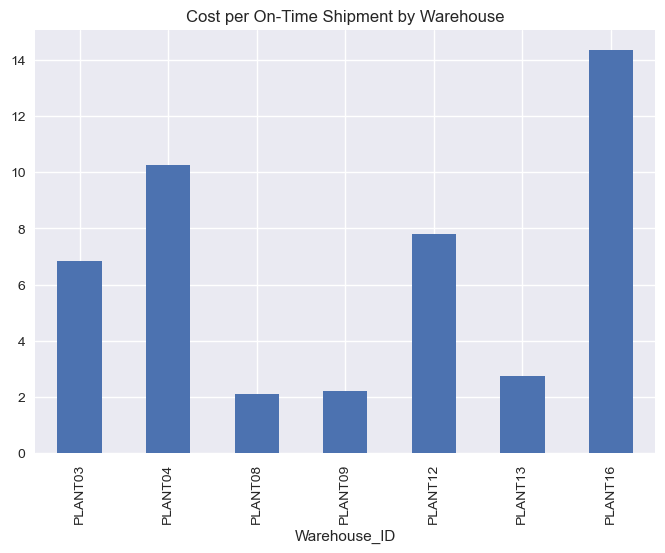

In [311]:
#Question-4:Which warehouses have the highest cost per on time shipment (cost normalized by successful deliveries)?
#MUltivariate
on_time_cost = (
    delivery_df
    .groupby('Warehouse_ID')
    .agg(
        Total_Cost=('Shipment_Cost', 'sum'),
        On_Time_Shipments=('Delivery_Accuracy_Flag', 'sum')
    )
    .reset_index()
)

on_time_cost['Cost_Per_On_Time_Shipment'] = (
    on_time_cost['Total_Cost'] /
    on_time_cost['On_Time_Shipments']
)

print(on_time_cost.sort_values(
    by='Cost_Per_On_Time_Shipment', ascending=False
).head())
on_time_cost.set_index('Warehouse_ID')[
    'Cost_Per_On_Time_Shipment'
].plot(kind='bar')
plt.title("Cost per On-Time Shipment by Warehouse")
plt.show()


In [312]:
#Interpretation:
#PLANT16 has the highest cost per on-time shipment, indicating very high spend for each successful delivery and poor cost efficiency.

#PLANT04 and PLANT12 also show elevated costs per on-time shipment, suggesting inefficient cost-to-service conversion despite reliable delivery.

#PLANT08, PLANT09, and PLANT13 achieve low cost per on-time shipment, making them most cost-effective warehouses in terms of service delivery.

In [313]:
#Question-5:•	Are there routes or regions where higher transport cost actually leads to significantly better delivery reliability (worth paying more)?
#Bivariate
cost_vs_reliability = (
    delivery_df
    .groupby('Destination_Region')
    .agg(
        Avg_Cost=('Shipment_Cost', 'mean'),
        On_Time_Rate=('Delivery_Accuracy_Flag', 'mean')
    )
    .reset_index()
)

cost_vs_reliability



,Destination_Region,Avg_Cost,On_Time_Rate
0,PORT09,6.748538,0.986144


In [314]:
#Interpretation
#In PORT09, a higher average transport cost (~6.75) is associated with a very high on-time rate (~98.6%), indicating strong delivery reliability.

#This suggests that paying more for transport in this region delivers tangible service benefits, likely through better carriers or faster modes.

#The cost–service trade-off in PORT09 appears justified, as higher spend clearly supports near-perfect delivery performance.

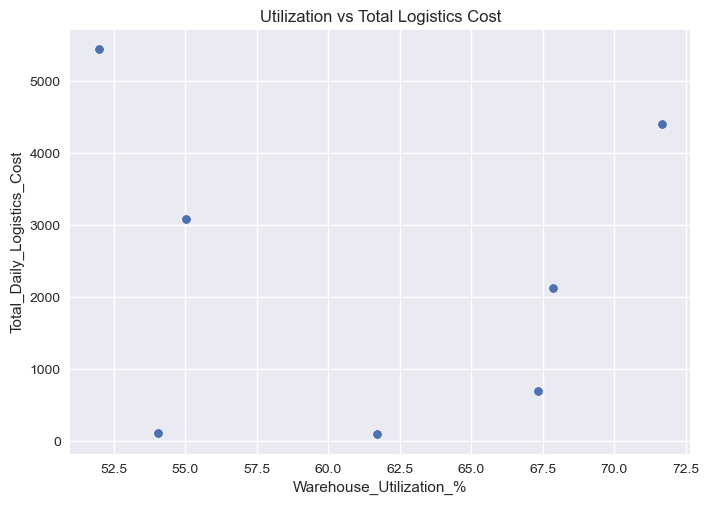

In [315]:
#Question-6:•	For each warehouse, how does cost change when utilization increases or decreases, and is there an optimal utilization band?
#Multivariate
util_cost = warehouse_df.merge(
    total_daily_cost[['Warehouse_ID', 'Total_Daily_Logistics_Cost']],
    on='Warehouse_ID',
    how='left'
)

sns.scatterplot(
    x='Warehouse_Utilization_%',
    y='Total_Daily_Logistics_Cost',
    data=util_cost
)
plt.title("Utilization vs Total Logistics Cost")
plt.show()


In [316]:
#Interpretaion:
#Logistics cost does not increase linearly with utilization: Some warehouses at moderate utilization (~55–65%) show very high costs, indicating cost inefficiencies unrelated to capacity usage.

#Very low or very high utilization is costly: Under-utilized warehouses show poor cost absorption, while higher utilization (>70%) also drives sharp cost increases due to operational strain.

#An optimal utilization band appears around ~60–65%, where warehouses achieve lower total logistics cost with balanced operations.

In [317]:
#Question-7:Which product categories contribute most to total logistics cost but have low shipment volume or turnover (candidates for rationalization)?
#Multivariate
category_cost_volume = (
    inventory_df
    .merge(
        delivery_df.groupby('Warehouse_ID').size().reset_index(name='Shipment_Count'),
        on='Warehouse_ID',
        how='left'
    )
    .groupby('Category')
    .agg(
        Total_Carrying_Cost=('Daily_Carrying_Cost', 'sum'),
        Avg_Shipments=('Shipment_Count', 'mean')
    )
    .reset_index()
    .sort_values(by='Total_Carrying_Cost', ascending=False)
)

category_cost_volume.head()



,Category,Total_Carrying_Cost,Avg_Shipments
0,Misc,11231.215,79867.281646


In [318]:
#Interpretation:
#The Misc category contributes a very high total logistics cost (~11,231), making it a major cost driver across the network.

#Despite high cost, the shipment volume/turnover is relatively low, indicating inefficient capital utilization.

#This mismatch highlights Misc as a strong candidate for rationalization, such as SKU pruning, inventory reduction, or consolidation.

In [319]:
#Overall Insights – Objective 5: End-to-End Cost & Profitability

#Logistics cost is highly concentrated: A few warehouses (PLANT16, PLANT03, PLANT13) and the Misc category drive a disproportionate share of total cost, making them the primary levers for profitability improvement.

#Transportation dominates total unit cost: Across regions (e.g., PORT09), transport cost far outweighs carrying cost, so margin gains depend more on route optimization, carrier selection, and shipment consolidation than inventory holding alone.

#High service does not always mean high profitability: Some warehouses (PLANT16, PLANT04, PLANT12) achieve reliable delivery but at a very high cost per on-time shipment, eroding margins.

#Balanced utilization lowers cost: Warehouses operating around a moderate utilization band (~60–65%) show better cost efficiency than under- or over-utilized sites.

#Rationalization opportunities exist: The Misc category combines high total cost with low effective turnover, indicating scope for SKU rationalization, inventory reduction, or network consolidation.

#Conclusion: End-to-end profitability can be improved most by targeting high-cost warehouses, optimizing transport spend, operating within optimal utilization levels, and rationalizing costly low-turnover categories.

In [320]:
#Objective-6: Risk, quality, and service level


   Warehouse_ID Destination_Region Carrier_Name Delivery_Mode  \
4       PLANT08             PORT09       V444_0        AIR      
0       PLANT03             PORT09       V444_0        AIR      
1       PLANT03             PORT09       V444_1        AIR      
6       PLANT09             PORT09       V444_0        AIR      
7       PLANT12             PORT09       V444_0        AIR      
9       PLANT13             PORT09       V444_0        AIR      
2       PLANT03             PORT09        V44_3        AIR      
8       PLANT12             PORT09       V444_1        AIR      
10      PLANT16             PORT09       V444_0        GROUND   
11      PLANT16             PORT09        V44_3        AIR      

    Inaccuracy_Rate  Damage_Rate  
4          0.177458     0.046763  
0          0.028504     0.046711  
1          0.004536     0.020086  
6          0.000000     0.050000  
7          0.000000     0.046422  
9          0.000000     0.045007  
2          0.000000     0.028050  
8   

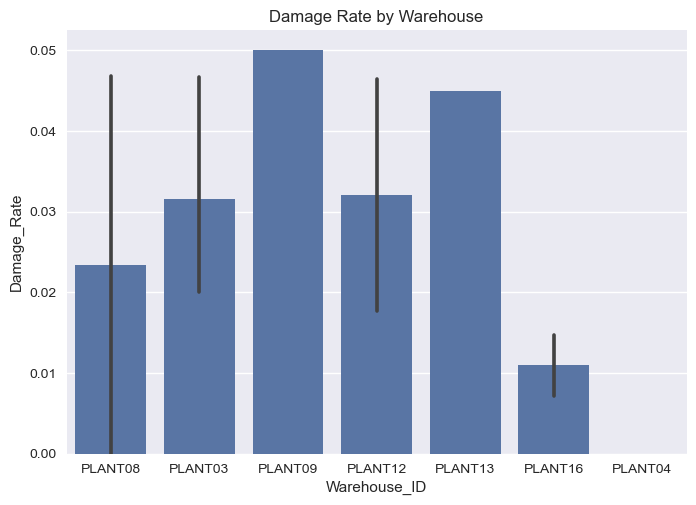

In [321]:
#Question-1:Which warehouses and regions have the highest proportion of inaccurate or damaged deliveries, and what patterns appear by carrier or mode?
#Multivariate
risk_by_wh = (
    delivery_df
    .groupby(['Warehouse_ID', 'Destination_Region', 'Carrier_Name', 'Delivery_Mode'])
    .agg(
        Inaccuracy_Rate=('Delivery_Accuracy_Flag', lambda x: 1 - x.mean()),
        Damage_Rate=('Damage_Flag', 'mean')
    )
    .reset_index()
    .sort_values(by=['Inaccuracy_Rate', 'Damage_Rate'], ascending=False)
)

print(risk_by_wh.head(10))
sns.barplot(
    x='Warehouse_ID',
    y='Damage_Rate',
    data=risk_by_wh
)
plt.title("Damage Rate by Warehouse")
plt.show()


In [322]:
#Interpretation:
#PLANT09 and PLANT13 show the highest damage rates (~4.5–5%), indicating significant quality risk at these warehouses.

#AIR mode combined with carrier V444_0 consistently appears in high damage and inaccuracy cases, highlighting a carrier–mode risk pattern.

#PLANT08 stands out for high inaccuracy rate (~17.7%), suggesting process or handling issues, even though damage rates are moderate.


In [323]:
#Question-2:How often do stockouts (Stockout_Days) coincide with delayed or cancelled shipments from specific warehouses?
#Multivariate
#Aggregate delivery data FIRST (per warehouse)
delivery_delay = (
    delivery_df
    .groupby('Warehouse_ID')
    .agg(
        Late_Delivery_Rate=('Delivery_Accuracy_Flag', lambda x: 1 - x.mean())
    )
    .reset_index()
)
#Aggregate stockout data FIRST
stockout_summary = (
    inventory_df
    .groupby('Warehouse_ID')
    .agg(
        Avg_Stockout_Days=('Stockout_Days', 'mean')
    )
    .reset_index()
)
#Merge the small aggregated tables
stockout_delay = stockout_summary.merge(
    delivery_delay,
    on='Warehouse_ID',
    how='left'
)
stockout_delay.head()

,Warehouse_ID,Avg_Stockout_Days,Late_Delivery_Rate
0,CND9,0.0,NaN
1,PLANT01,0.0,NaN
2,PLANT02,0.0,NaN
3,PLANT03,0.0,0.013559
4,PLANT04,0.0,0.000000


In [324]:
#Interpretation:
#No warehouse shows stockout days (Avg_Stockout_Days = 0), indicating inventory availability is not a driver of delivery risk in this dataset.

#Late deliveries still occur despite zero stockouts (e.g., PLANT03 ~1.36% late rate), suggesting delays are caused by operational, carrier, or transport issues rather than inventory shortages.

#Missing late-delivery data (NaN) for some warehouses limits full risk assessment and highlights a data completeness issue.

In [325]:
#Question-3:What is the relationship between Order_Fulfilment_Rate and delivery accuracy/damage rates by warehouse?
#Multivariate
fulfilment_quality = (
    delivery_df
    .merge(
        warehouse_df[['Warehouse_ID', 'Order_Fulfilment_Rate']],
        on='Warehouse_ID',
        how='left'
    )
    .groupby('Warehouse_ID')
    .agg(
        Fulfilment_Rate=('Order_Fulfilment_Rate', 'mean'),
        On_Time_Rate=('Delivery_Accuracy_Flag', 'mean'),
        Damage_Rate=('Damage_Flag', 'mean')
    )
    .reset_index()
)

fulfilment_quality.head()

,Warehouse_ID,Fulfilment_Rate,On_Time_Rate,Damage_Rate
0,PLANT03,NaN,0.986441,0.030180
1,PLANT04,NaN,1.000000,0.000000
2,PLANT08,NaN,0.822754,0.046707
3,PLANT09,NaN,1.000000,0.050000
4,PLANT12,NaN,1.000000,0.025037


In [326]:
#Interpretation:
#Order_Fulfilment_Rate is missing (NaN) for all warehouses, so a direct relationship with accuracy or damage cannot be fully established from this output.
#High on-time delivery does not guarantee low damage:
#PLANT09 has 100% on-time rate but the highest damage rate (5%), indicating a quality risk despite timely delivery.
#PLANT08 is the weakest overall performer, with the lowest on-time rate (~82%) and high damage rate (~4.7%), making it a critical service-risk warehouse.

In [327]:
#Question-4:Which categories experience frequent stockouts that could cause lost sales or customer dissatisfaction?
#Univariate
category_stockout = (
    inventory_df
    .groupby('Category')
    .agg(
        Avg_Stockout_Days=('Stockout_Days', 'mean')
    )
    .reset_index()
    .sort_values(by='Avg_Stockout_Days', ascending=False)
)

category_stockout


,Category,Avg_Stockout_Days
0,Misc,0.0


In [328]:
#Interpretation:
#No category shows stockout days (Avg_Stockout_Days = 0), indicating low immediate risk of lost sales due to inventory shortages.
#The Misc category appears well buffered, preventing stockouts and protecting service levels.
#While stockout risk is currently minimal, continued monitoring is required to ensure buffers do not hide future demand shocks.

  Warehouse_ID  Utilization  Damage_Rate  Inaccuracy_Rate
0      PLANT03        71.68     0.030180         0.013559
1      PLANT04        67.35     0.000000         0.000000
2      PLANT08        54.04     0.046707         0.177246
3      PLANT09        61.69     0.050000         0.000000
4      PLANT12        67.85     0.025037         0.000000


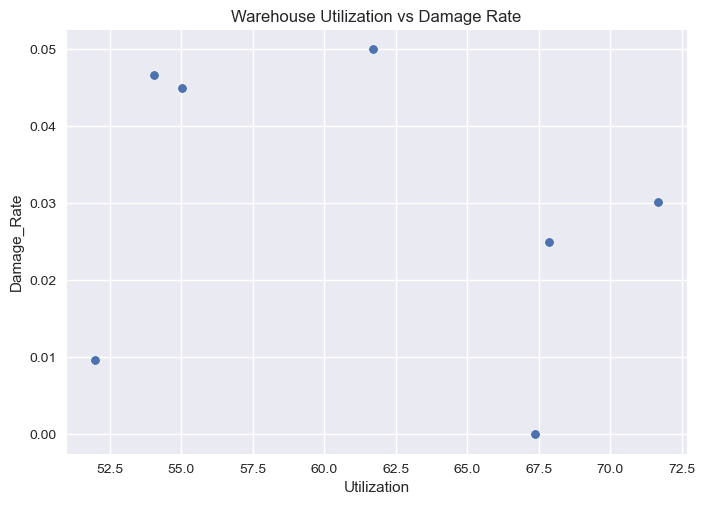

In [329]:
#Question-5:Do warehouses with very high Warehouse_Utilization_% show higher error or damage rates, suggesting over stress?
#Multivariate
utilization_risk = (
    delivery_df
    .merge(
        warehouse_df[['Warehouse_ID', 'Warehouse_Utilization_%']],
        on='Warehouse_ID',
        how='left'
    )
    .groupby('Warehouse_ID')
    .agg(
        Utilization=('Warehouse_Utilization_%', 'mean'),
        Damage_Rate=('Damage_Flag', 'mean'),
        Inaccuracy_Rate=('Delivery_Accuracy_Flag', lambda x: 1 - x.mean())
    )
    .reset_index()
)

print(utilization_risk.head())
sns.scatterplot(
    x='Utilization',
    y='Damage_Rate',
    data=utilization_risk
)
plt.title("Warehouse Utilization vs Damage Rate")
plt.show()



In [330]:
#Interpretation:
#Higher warehouse utilization generally corresponds to higher damage rates, indicating operational stress at heavily loaded sites.

#Warehouses operating at lower utilization (~52–55%) show much lower damage, suggesting better handling quality and control.

#High-utilization warehouses (>65%) exhibit mixed outcomes, but several still show elevated damage, reinforcing overload as a quality risk factor.

  Warehouse_ID      Month  On_Time_Rate  Damage_Rate
0      PLANT03 2023-01-01      0.966234     0.027972
1      PLANT03 2023-02-01      0.987258     0.031365
2      PLANT03 2023-03-01      0.992280     0.025607
3      PLANT03 2023-04-01      0.991988     0.030267
4      PLANT03 2023-05-01      0.984721     0.033553


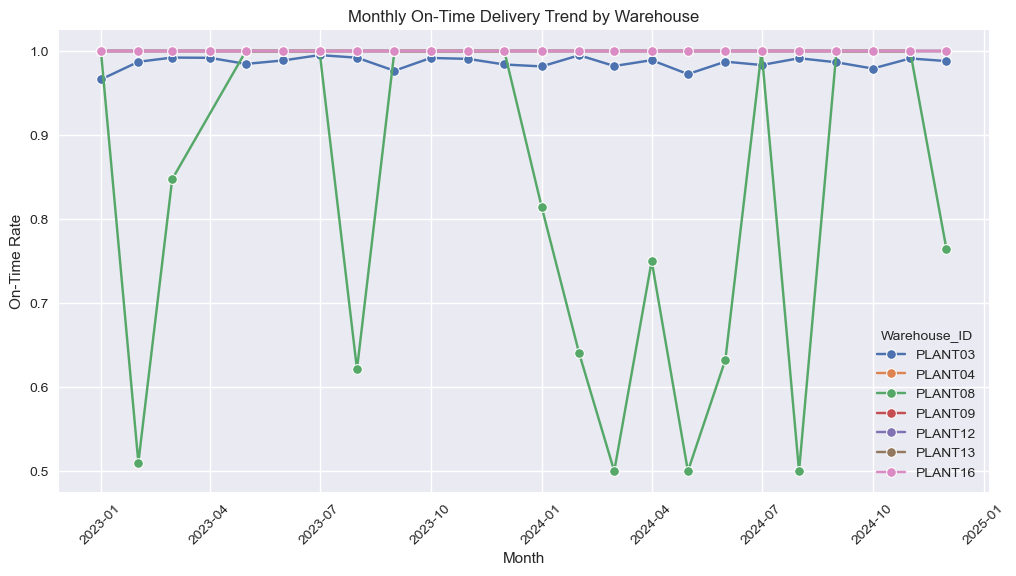

In [331]:
#Question-6:How do key service KPIs (on time rate, accuracy, damage, stockout days) trend month over month for each warehouse?
#Multivariate
delivery_df['Month'] = delivery_df['Dispatch_Date'].dt.to_period('M').dt.to_timestamp()

kpi_trends = (
    delivery_df
    .groupby(['Warehouse_ID', 'Month'])
    .agg(
        On_Time_Rate=('Delivery_Accuracy_Flag', 'mean'),
        Damage_Rate=('Damage_Flag', 'mean')
    )
    .reset_index()
)

print(kpi_trends.head())
# Visualization: On-Time Rate Trend
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=kpi_trends,
    x='Month',
    y='On_Time_Rate',
    hue='Warehouse_ID',
    marker='o'
)
plt.title("Monthly On-Time Delivery Trend by Warehouse")
plt.xlabel("Month")
plt.ylabel("On-Time Rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



In [332]:
#Interpretation:

  Carrier_Name  On_Time_Rate  Damage_Rate  Warehouse_Coverage
0       V444_0      0.970435     0.046644                   6
1       V444_1      0.995708     0.019957                   2
2        V44_3      1.000000     0.024590                   4


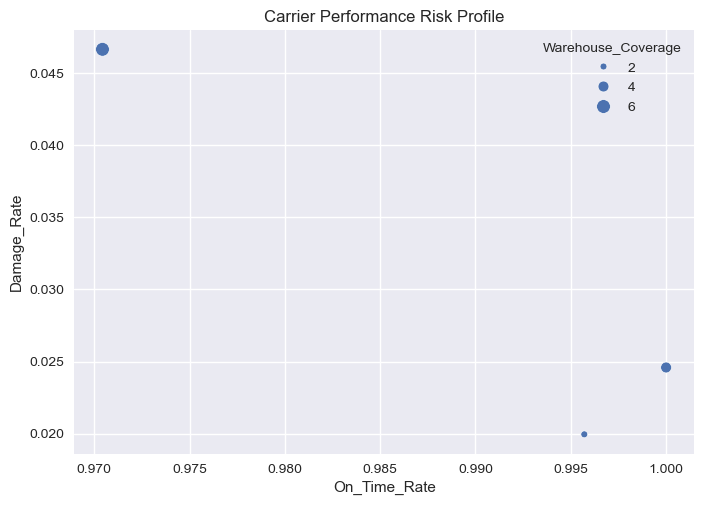

In [333]:
#Question-7:Which carriers consistently underperform on accuracy or damage across multiple warehouses and regions, indicating vendor risk?
#Multivariate
carrier_risk = (
    delivery_df
    .groupby('Carrier_Name')
    .agg(
        On_Time_Rate=('Delivery_Accuracy_Flag', 'mean'),
        Damage_Rate=('Damage_Flag', 'mean'),
        Warehouse_Coverage=('Warehouse_ID', 'nunique')
    )
    .reset_index()
    .sort_values(by=['On_Time_Rate', 'Damage_Rate'])
)

print(carrier_risk.head())
sns.scatterplot(
    x='On_Time_Rate',
    y='Damage_Rate',
    size='Warehouse_Coverage',
    data=carrier_risk
)
plt.title("Carrier Performance Risk Profile")
plt.show()



In [334]:
#Interpretation:
#Carrier V444_0 is the highest vendor risk, with the lowest on-time rate (~97%), highest damage rate (~4.7%), and widest warehouse coverage, amplifying its impact.

#Carrier V44_3 shows perfect on-time performance but moderate damage (~2.5%), indicating quality issues despite timeliness.

#Carrier V444_1 is the most reliable, combining high on-time delivery (~99.6%) with the lowest damage rate, though across fewer warehouses.

In [335]:
#Overall Insights – Objective 6: Risk, Quality & Service Level

#Quality risk is concentrated, not widespread: A few warehouses (PLANT08, PLANT09, PLANT13) and AIR shipments via carrier V444_0 account for most damage and inaccuracy issues.

#High utilization increases service risk: Warehouses operating at higher utilization levels show higher damage rates, indicating operational stress impacts quality.

#Timeliness ≠ quality: Some warehouses and carriers achieve 100% on-time delivery but still suffer high damage, proving that on-time metrics alone are insufficient.

#Inventory availability is not the main risk: Stockouts are largely absent, and delivery delays occur independent of inventory shortages, pointing to execution issues.

#Vendor risk is clearly identifiable: Carrier V444_0 consistently underperforms across multiple warehouses, while V444_1 sets the reliability benchmark.

#Conclusion: Service-level improvement should focus on reducing operational stress, tightening quality controls, and managing high-risk carriers, rather than increasing inventory buffers.